#### **IMPORTING LIBRARIES AND SETTINGS**

In [161]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Machine Learning libraries
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, roc_curve, precision_recall_curve
)
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


# Visualization settings
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8')
sns.set_theme(style='whitegrid', palette='bright')

print("All libraries imported successfully")
print(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

All libraries imported successfully
Analysis Date: 2026-05-29 03:26:11


### **LOADING THE DATASET**

This task focuses on loading the raw CSV dataset into a Jupyter Notebook environment and performing a comprehensive initial investigation of the dataset. The goal is to understand the structure, schema, and statistical properties of the hydraulic sensor data used at Bosch Rexroth AG. This step is critical because it establishes foundational awareness of what variables are available, how the data is organized, and whether there are any immediate quality concerns before deeper analysis begins.

##### **Task**
- Loading the CSV dataset into Jupyter Notebook using pandas
- Inspecting dataset dimensions (rows and columns)
- Identifying data types of each feature
- Displaying sample records (head, tail, random samples)
- Listing all available features and categorize them:

  - Sensor variables

  - Target variables

  - Metadata (if any)

- Generating the summary statistics (mean, std, min, max)
- Identifying potential data quality issues
- Documenting the initial dataset understanding

##### **Inspecting the data on all four tables**

In [162]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [163]:
sensor_df = pd.read_csv("/content/drive/MyDrive/predictive maintenance project/sensor_telemetry_cleaneed.csv")
maintenance_df  = pd.read_csv("/content/drive/MyDrive/predictive maintenance project/maintenance_log.csv")
equipment_df  = pd.read_csv("/content/drive/MyDrive/predictive maintenance project/equipment_master.csv")
failure_df   = pd.read_csv("/content/drive/MyDrive/predictive maintenance project/failure_labels.csv")


In [164]:
# Creating a dataset dictionary for group inspection
dataset_dict = {"sensor_df": sensor_df, "maintenance_df": maintenance_df, "equipment_df": equipment_df, "failure_df": failure_df}
#inspecting the dataset by checking the first five rows
for name, df in dataset_dict.items():
    print('=' * 60)
    print(f"dataset: {name}\n")
    display(df.head())


dataset: sensor_df



,timestamp,machine_id,pressure_bar,temp_celsius,flow_lpm,vibration_x_g,vibration_y_g,pump_rpm,is_anomaly,failure_mode,rul_hours,is_sensor_dropout,shift,day_of_week
0,01/02/2024 03:15,HPU_01,128.10,51.69,85.60,0.0665,0.0665,1472.0,1,pump_wear,332.8,0,Night,3
1,01/02/2024 03:16,HPU_01,126.68,52.33,87.94,0.0799,0.0799,1471.0,1,pump_wear,332.7,0,Night,3
2,01/02/2024 03:17,HPU_01,124.49,51.79,88.07,0.0948,0.0948,1468.0,1,pump_wear,332.7,0,Night,3
3,01/02/2024 03:18,HPU_01,124.14,51.80,89.51,0.1232,0.1232,1471.0,1,pump_wear,332.7,0,Night,3
4,01/02/2024 03:19,HPU_01,124.88,50.97,86.94,0.0515,0.0515,1473.0,1,pump_wear,332.7,0,Night,3


dataset: maintenance_df



,maintenance_id,machine_id,action_timestamp,action_type,component_replaced,technician_id,cost_usd
0,M_026,HPU_05,03/10/2023 17:09,Reactive,Valve,T_001,7840
1,M_009,HPU_02,04/10/2023 20:06,Preventive,Filter,T_002,1896
2,M_036,HPU_08,06/10/2023 07:26,Preventive,Seal,T_004,738
3,M_023,HPU_05,07/10/2023 07:47,Preventive,Oil,T_001,1476
4,M_015,HPU_03,10/10/2023 06:41,Preventive,Seal,T_008,707


dataset: equipment_df



,machine_id,installation_date,total_operating_hours,fluid_type,last_filter_change_date,maintenance_priority
0,HPU_01,2023-03-13,14012,mineral_oil,2023-12-19,Low
1,HPU_02,2022-10-28,9572,mineral_oil,2023-11-24,Medium
2,HPU_03,2023-03-23,7848,mineral_oil,2023-10-14,Low
3,HPU_04,2022-04-29,5976,mineral_oil,2023-12-18,High
4,HPU_05,2023-04-01,12623,mineral_oil,2023-11-25,Low


dataset: failure_df



,failure_event_id,machine_id,failure_timestamp,failure_mode,degradation_start_timestamp,repair_cost_usd,downtime_hours
0,F_001,HPU_01,2024-02-15,pump_wear,2024-02-01,25094,13.2
1,F_002,HPU_02,2024-02-22,valve_leakage,2024-02-12,8711,9.8
2,F_003,HPU_03,2024-02-08,contamination,2024-02-03,24507,6.3
3,F_004,HPU_04,2024-02-28,pump_wear,2024-02-16,29482,22.4
4,F_005,HPU_05,2024-01-31,valve_leakage,2024-01-21,14065,8.2


##### **Checking the dimension of the datasets (all four dataset)**

In [165]:
# checking dataset dimension
print("=" * 60)
print("DATASET DIMENSION")
print("=" * 60)
for name, dataset in dataset_dict.items():
    print(f"  {name:<22}: {dataset.shape[0]:>8,} rows × {dataset.shape[1]} cols")
print("=" * 60)

DATASET DIMENSION
  sensor_df             :  864,000 rows × 14 cols
  maintenance_df        :       51 rows × 7 cols
  equipment_df          :       10 rows × 6 cols
  failure_df            :        9 rows × 7 cols


##### **Checking the data information for all the datasets**

In [166]:
# Dataset information check
for name, df in dataset_dict.items():
    print('=' * 60)
    print(f"dataset: {name}\n")
    # print('=' * 60)
    display(df.info())


dataset: sensor_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 864000 entries, 0 to 863999
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   timestamp          864000 non-null  object 
 1   machine_id         864000 non-null  object 
 2   pressure_bar       861410 non-null  float64
 3   temp_celsius       861410 non-null  float64
 4   flow_lpm           861410 non-null  float64
 5   vibration_x_g      861410 non-null  float64
 6   vibration_y_g      861410 non-null  float64
 7   pump_rpm           861410 non-null  float64
 8   is_anomaly         864000 non-null  int64  
 9   failure_mode       864000 non-null  object 
 10  rul_hours          864000 non-null  float64
 11  is_sensor_dropout  864000 non-null  int64  
 12  shift              864000 non-null  object 
 13  day_of_week        864000 non-null  int64  
dtypes: float64(7), int64(3), object(4)
memory usage: 92.3+ MB


None

dataset: maintenance_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   maintenance_id      51 non-null     object
 1   machine_id          51 non-null     object
 2   action_timestamp    51 non-null     object
 3   action_type         51 non-null     object
 4   component_replaced  42 non-null     object
 5   technician_id       51 non-null     object
 6   cost_usd            51 non-null     int64 
dtypes: int64(1), object(6)
memory usage: 2.9+ KB


None

dataset: equipment_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   machine_id               10 non-null     object
 1   installation_date        10 non-null     object
 2   total_operating_hours    10 non-null     int64 
 3   fluid_type               10 non-null     object
 4   last_filter_change_date  10 non-null     object
 5   maintenance_priority     10 non-null     object
dtypes: int64(1), object(5)
memory usage: 612.0+ bytes


None

dataset: failure_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   failure_event_id             9 non-null      object 
 1   machine_id                   9 non-null      object 
 2   failure_timestamp            9 non-null      object 
 3   failure_mode                 9 non-null      object 
 4   degradation_start_timestamp  9 non-null      object 
 5   repair_cost_usd              9 non-null      int64  
 6   downtime_hours               9 non-null      float64
dtypes: float64(1), int64(1), object(5)
memory usage: 636.0+ bytes


None

##### **Checking for missing values in all four datasets**

In [167]:
# Check for missing values
for name, df in dataset_dict.items():
    print('=' * 60)
    print(f"dataset: {name}\n")
    display(df.isna().sum())


dataset: sensor_df



,0
timestamp,0
machine_id,0
pressure_bar,2590
temp_celsius,2590
flow_lpm,2590
vibration_x_g,2590
vibration_y_g,2590
pump_rpm,2590
is_anomaly,0
failure_mode,0


dataset: maintenance_df



,0
maintenance_id,0
machine_id,0
action_timestamp,0
action_type,0
component_replaced,9
technician_id,0
cost_usd,0


dataset: equipment_df



,0
machine_id,0
installation_date,0
total_operating_hours,0
fluid_type,0
last_filter_change_date,0
maintenance_priority,0


dataset: failure_df



,0
failure_event_id,0
machine_id,0
failure_timestamp,0
failure_mode,0
degradation_start_timestamp,0
repair_cost_usd,0
downtime_hours,0


##### **Checking for duplicated datas in the datasets**

In [168]:
# Check for duplicates
for name, df in dataset_dict.items():
    print('=' * 60)
    print(f"dataset: {name}")
    display(df.duplicated().sum())


dataset: sensor_df


np.int64(0)

dataset: maintenance_df


np.int64(0)

dataset: equipment_df


np.int64(0)

dataset: failure_df


np.int64(0)

##### **Checking for datatypes**

In [169]:
# Check for datatypes
for name, df in dataset_dict.items():
    print('=' * 60)
    print(f"dataset: {name}")
    display(df.dtypes)


dataset: sensor_df


,0
timestamp,object
machine_id,object
pressure_bar,float64
temp_celsius,float64
flow_lpm,float64
vibration_x_g,float64
vibration_y_g,float64
pump_rpm,float64
is_anomaly,int64
failure_mode,object


dataset: maintenance_df


,0
maintenance_id,object
machine_id,object
action_timestamp,object
action_type,object
component_replaced,object
technician_id,object
cost_usd,int64


dataset: equipment_df


,0
machine_id,object
installation_date,object
total_operating_hours,int64
fluid_type,object
last_filter_change_date,object
maintenance_priority,object


dataset: failure_df


,0
failure_event_id,object
machine_id,object
failure_timestamp,object
failure_mode,object
degradation_start_timestamp,object
repair_cost_usd,int64
downtime_hours,float64


##### **Checking for unique values in all the datasets**

In [170]:
# Check for unique values
for name, df in dataset_dict.items():
    print('=' * 60)
    print(f"dataset: {name}")
    display(df.nunique())


dataset: sensor_df


,0
timestamp,86400
machine_id,10
pressure_bar,9509
temp_celsius,1916
flow_lpm,5526
vibration_x_g,12925
vibration_y_g,12922
pump_rpm,100
is_anomaly,2
failure_mode,5


dataset: maintenance_df


,0
maintenance_id,51
machine_id,10
action_timestamp,51
action_type,3
component_replaced,5
technician_id,8
cost_usd,50


dataset: equipment_df


,0
machine_id,10
installation_date,9
total_operating_hours,10
fluid_type,2
last_filter_change_date,9
maintenance_priority,3


dataset: failure_df


,0
failure_event_id,9
machine_id,9
failure_timestamp,9
failure_mode,4
degradation_start_timestamp,8
repair_cost_usd,9
downtime_hours,9


##### **Checking for Summary statistics on all four datasets**

In [171]:
# Check for summary statistics
for name, df in dataset_dict.items():
    print('=' * 60)
    print(f"dataset: {name}\n")
    display(df.describe())


dataset: sensor_df



,pressure_bar,temp_celsius,flow_lpm,vibration_x_g,vibration_y_g,pump_rpm,is_anomaly,rul_hours,is_sensor_dropout,day_of_week
count,861410.000000,861410.000000,861410.000000,861410.000000,861410.000000,861410.000000,864000.000000,864000.000000,864000.000000,864000.000000
mean,123.745802,52.218564,86.145165,0.143306,0.142908,1479.726617,0.146667,323.167889,0.002998,2.900000
std,16.610808,2.281346,10.850925,0.365332,0.365400,68.261889,0.353774,226.183963,0.054669,1.989138
min,42.960000,-9.940000,31.250000,0.050000,0.050000,1000.000000,0.000000,0.000000,0.000000,0.000000
25%,113.000000,51.080000,77.280000,0.051500,0.051000,1463.000000,0.000000,8.000000,0.000000,1.000000
50%,125.920000,52.170000,88.170000,0.089900,0.089600,1480.000000,0.000000,500.000000,0.000000,3.000000
75%,136.620000,53.120000,94.870000,0.147000,0.146500,1518.000000,0.000000,500.000000,0.000000,5.000000
max,598.470000,64.860000,108.130000,14.739100,14.965300,1540.000000,1.000000,500.000000,1.000000,6.000000


dataset: maintenance_df



,cost_usd
count,51.000000
mean,1921.607843
std,1745.885839
min,306.000000
25%,801.500000
50%,1268.000000
75%,2330.000000
max,7840.000000


dataset: equipment_df



,total_operating_hours
count,10.000000
mean,12329.100000
std,5820.897343
min,5869.000000
25%,8279.000000
50%,11427.000000
75%,14081.750000
max,24309.000000


dataset: failure_df



,repair_cost_usd,downtime_hours
count,9.000000,9.000000
mean,20366.222222,11.855556
std,7878.436961,4.766841
min,8711.000000,6.300000
25%,14065.000000,8.700000
50%,23021.000000,10.500000
75%,25094.000000,13.200000
max,30336.000000,22.400000


The predictive maintenance project is built on four interconnected datasets containing sensor telemetry, failure events, maintenance history, and equipment metadata for hydraulic systems. An initial data assessment was conducted to understand the structure.

1. Sensor Telemetry Dataset (sensor_df)

The sensor_df dataset is the largest and most important dataset in the project, containing 864,000 records and 14 features representing high-frequency time-series sensor telemetry from hydraulic machines. The dataset includes operational parameters such as hydraulic pressure, oil temperature, flow rate, vibration measurements, and pump rotational speed, alongside contextual variables such as anomaly indicators, Remaining Useful Life (RUL), operational shift, and day of the week.

The Initial inspection showed No duplicate records were present.
Several sensor-related variables (pressure_bar, temp_celsius, flow_lpm, vibration_x_g, vibration_y_g, and pump_rpm) contained missing values, each with approximately 2,590 missing observations.
Timestamp-related variables were stored as object datatype rather than proper datetime format and would require conversion during preprocessing.
Binary variables such as is_anomaly and is_sensor_dropout were stored as integers and may later be converted into boolean or categorical types for improved interpretability.
The dataset combines continuous numerical variables with categorical operational features, making it suitable for both time-series analysis and predictive modeling.

Overall, the telemetry dataset provides a rich representation of machine behavior and forms the core foundation for failure prediction and Remaining Useful Life (RUL) estimation.

2. Failure Events Dataset (failure_df)

The failure_df dataset contains 9 failure event records across hydraulic machines and includes information such as failure timestamps, degradation start times, repair costs, downtime duration, and failure modes.

Initial findings include no duplicate or missing values were detected.
Timestamp variables (failure_timestamp and degradation_start_timestamp) were stored as object datatypes and will require conversion to datetime format.
The dataset contains structured failure labels that are essential for supervised learning tasks such as failure classification and RUL labeling.
The relatively small number of failure events suggests that the project may face class imbalance challenges during modeling.

This dataset serves as the primary source for identifying breakdown events and constructing predictive targets.

3. Maintenance Actions Dataset (maintenance_df)

The maintenance_df dataset contains 51 maintenance records documenting historical maintenance interventions performed on hydraulic machines. Features include maintenance timestamps, maintenance type, replaced components, technician identifiers, and associated maintenance costs.

Initial assessment revealed: No duplicate records were present.
One variable, component_replaced, contained 9 missing values, which may indicate maintenance activities where no component replacement occurred or where the information was not recorded.
Timestamp variables were stored as object datatype and require datetime conversion.
The dataset provides important operational context that can later be transformed into predictive features such as maintenance frequency, time since last maintenance, and maintenance history trends.

4. Equipment Metadata Dataset (equipment_df)

The equipment_df dataset contains 10 records representing static machine-level metadata for hydraulic equipment. Features include installation dates, total operating hours, fluid type, filter change history, and maintenance priority classification.

The Initial observations showed: No duplicate or missing values were detected. Date-related variables (installation_date and last_filter_change_date) were stored as object datatype and will require conversion to datetime format.
The dataset contains static machine characteristics that can enrich the telemetry dataset during merging and support machine-level analysis.

### **EXPLORATORY DATA ANALYSIS**
This task involves conducting a deep exploratory analysis of the dataset to uncover hidden patterns, distributions, correlations, and anomalies within the hydraulic sensor data. The objective is to understand how sensor readings behave under normal and failure conditions, identify early warning signals, and explore relationships between variables that may contribute to equipment failure prediction. This stage is essential for forming hypotheses and guiding feature engineering decisions.

##### **Task**
- Perform univariate analysis of all sensor variables
- Plot distributions for pressure, temperature, vibration, and flow
- Conduct time-series visualization of sensor behavior
- Perform correlation analysis between all numerical features
- Identify relationships between sensors and failure indicators
- Detect anomalies, spikes, and unusual sensor behavior
- Analyze trends leading up to failure events
- Summarize key behavioral patterns in dataset

##### **Univariate analysis**

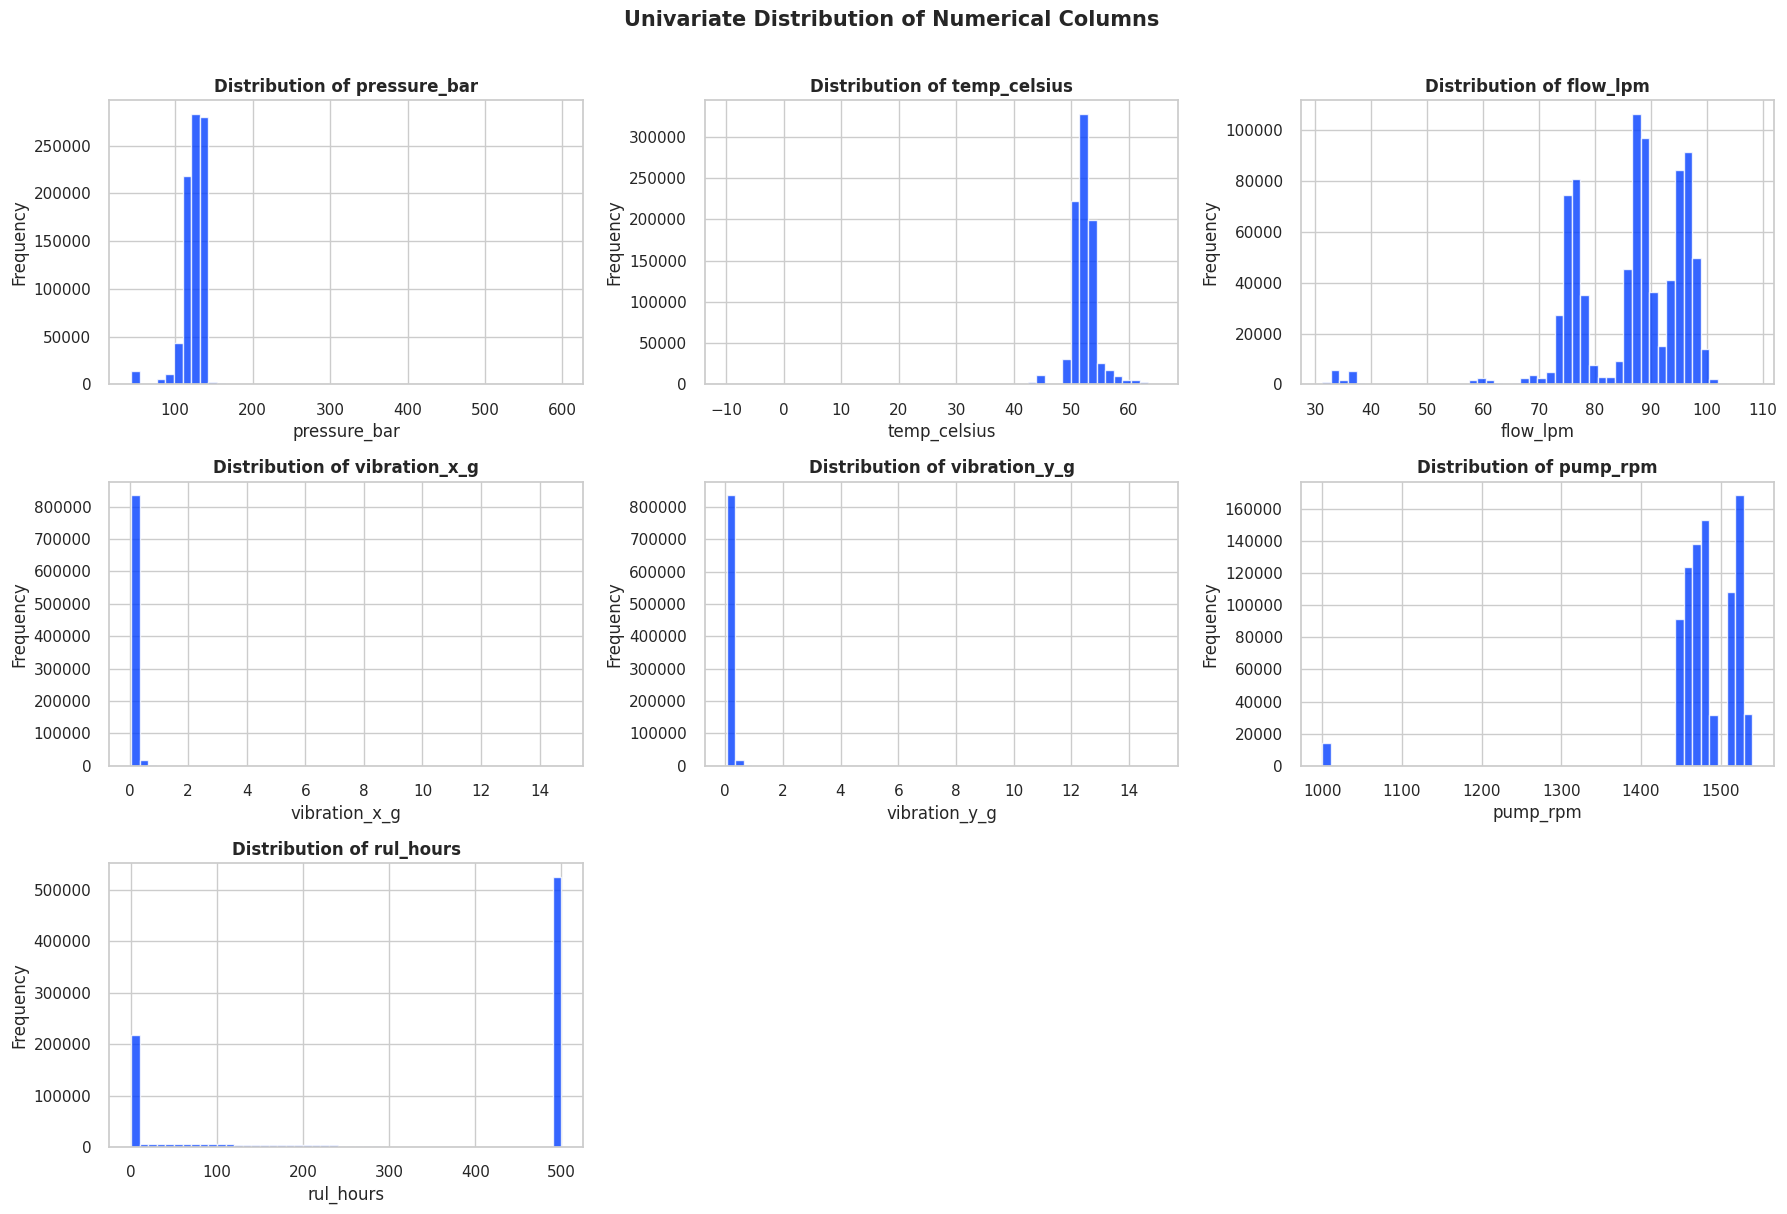

In [172]:
# Univariant distribution of numerical sensor variables
numerical_cols = ['pressure_bar', 'temp_celsius', 'flow_lpm',
                  'vibration_x_g', 'vibration_y_g', 'pump_rpm', 'rul_hours']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(sensor_df[col], bins=50, alpha=0.8)
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide unused subplots
for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Distribution of Numerical Columns', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

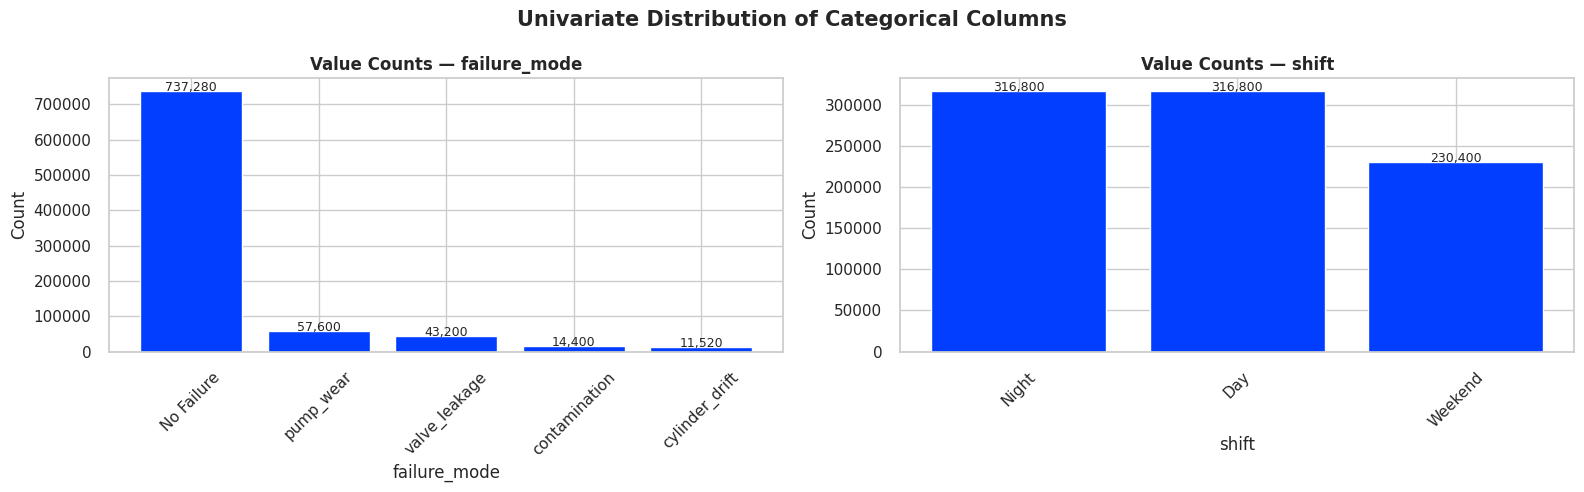

In [173]:
# Univariant distribution of categorical Variables
categorical_cols = ['failure_mode', 'shift']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, col in enumerate(categorical_cols):
    value_counts = sensor_df[col].value_counts()
    axes[i].bar(value_counts.index, value_counts.values,
                )
    axes[i].set_title(f'Value Counts — {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

    # add labels to bars
    for j, v in enumerate(value_counts.values):
        axes[i].text(j, v + 500, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Univariate Distribution of Categorical Columns',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

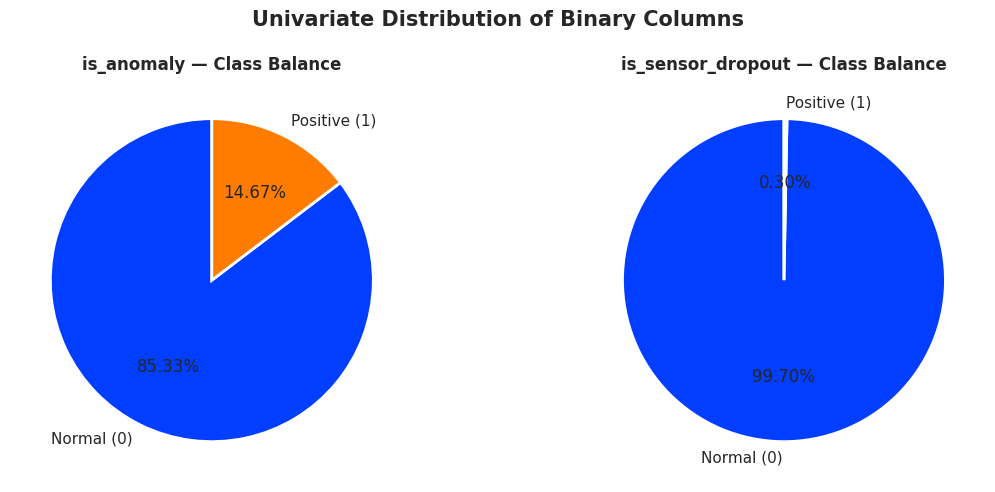

In [174]:
# Univariant Distribution of binary Variables
#binary columns
binary_cols = ['is_anomaly', 'is_sensor_dropout']

# visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, col in enumerate(binary_cols):
    counts = sensor_df[col].value_counts()
    labels = ['Normal (0)', 'Positive (1)']

    axes[i].pie(counts.values, labels=labels,
                autopct='%1.2f%%', startangle=90,
                wedgeprops=dict(edgecolor='white', linewidth=2))
    axes[i].set_title(f'{col} — Class Balance', fontsize=12, fontweight='bold')

plt.suptitle('Univariate Distribution of Binary Columns',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

##### **Bivariant analysis**

In [175]:
sensor_df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
pressure_bar,861410.0,123.745802,16.610808,42.96,113.0000,125.9200,136.6200,598.4700
temp_celsius,861410.0,52.218564,2.281346,-9.94,51.0800,52.1700,53.1200,64.8600
flow_lpm,861410.0,86.145165,10.850925,31.25,77.2800,88.1700,94.8700,108.1300
vibration_x_g,861410.0,0.143306,0.365332,0.05,0.0515,0.0899,0.1470,14.7391
vibration_y_g,861410.0,0.142908,0.365400,0.05,0.0510,0.0896,0.1465,14.9653
pump_rpm,861410.0,1479.726617,68.261889,1000.00,1463.0000,1480.0000,1518.0000,1540.0000
rul_hours,864000.0,323.167889,226.183963,0.00,8.0000,500.0000,500.0000,500.0000


##### **Distributions for sensor variables**

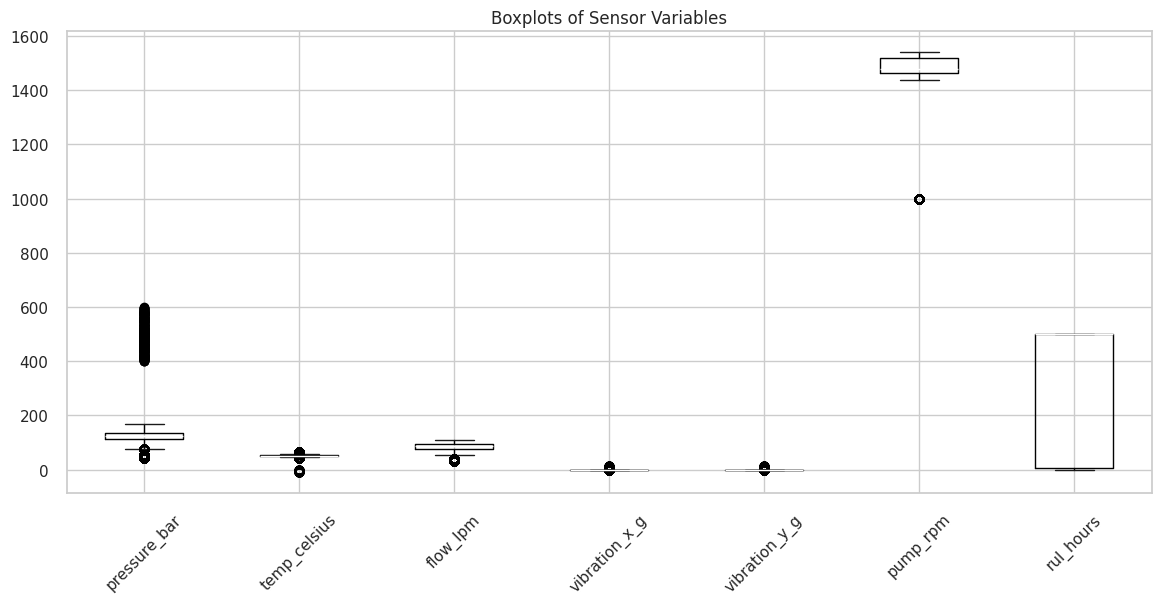

In [176]:
#Boxplots of Sensor Variables to investigate outliers in the variables
plt.figure(figsize=(14,6))

sensor_df[numerical_cols].boxplot()

plt.title("Boxplots of Sensor Variables")
plt.xticks(rotation=45)
plt.show()

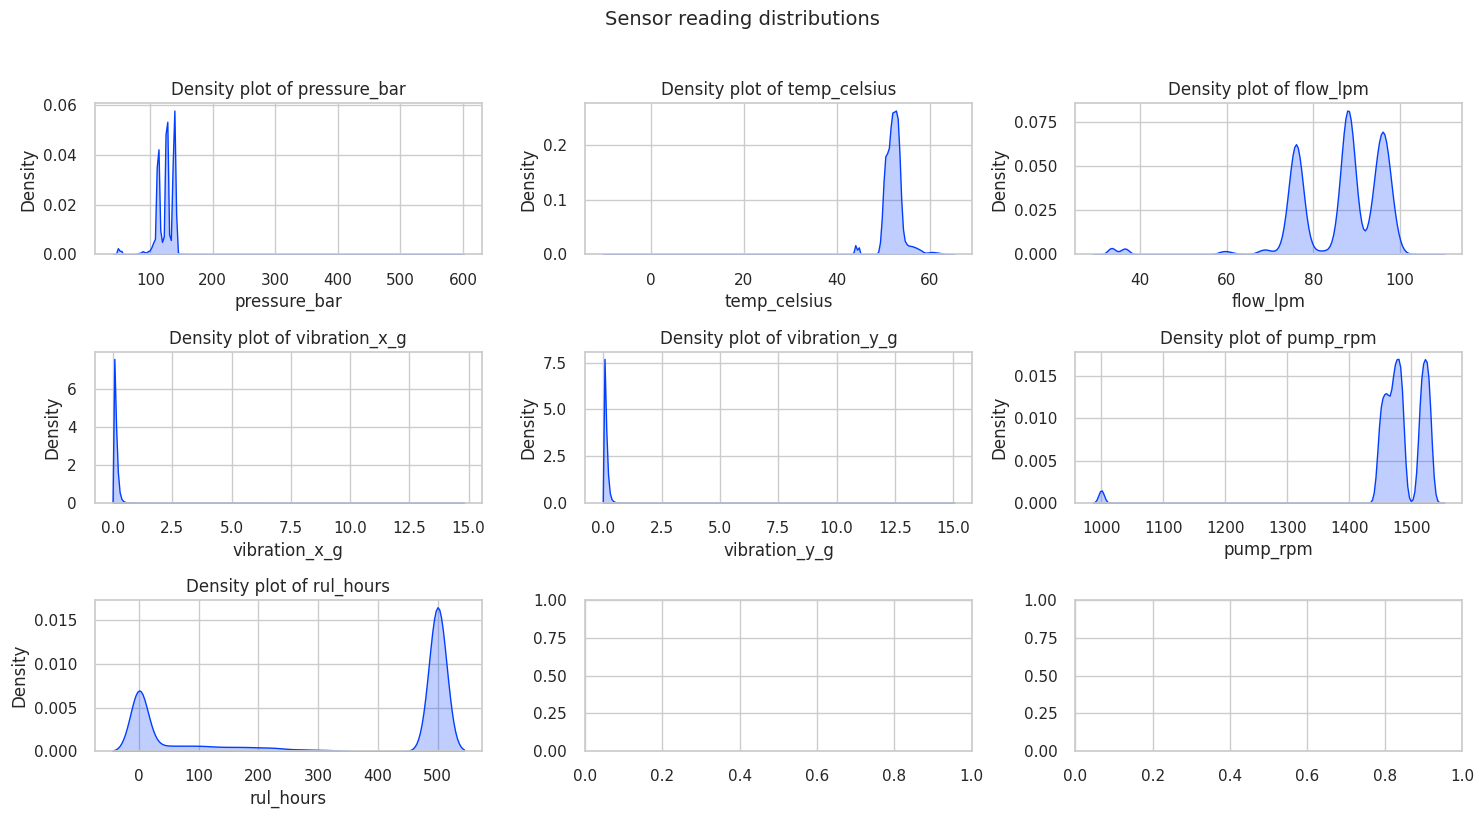

In [177]:
# Sensor reading distributions
fig, axes = plt.subplots(3, 3, figsize=(15, 8))

for ax, col in zip(axes.flat, numerical_cols):
    sns.kdeplot(data=sensor_df, x=col, fill=True, ax=ax)
    ax.set_title(f'Density plot of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')

# Hide unused subplots
for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Sensor reading distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The univariate analysis of sensor telemetry variables revealed generally stable operational distributions across pressure, temperature, flow rate, vibration, and pump speed measurements. However, several variables, particularly vibration-related features, exhibited noticeable outliers and wider variability, potentially indicating abnormal machine behavior or degradation patterns. Missing values were observed consistently across sensor measurements and are likely associated with sensor dropout events. The analysis also highlighted differing distribution shapes among variables, suggesting that normalization and feature scaling may be required during preprocessing.

##### **Time series visualization of sensor variable**

In [178]:
sensor_df['timestamp'] = pd.to_datetime(
    sensor_df['timestamp'],
    format='%d/%m/%Y %H:%M'
)

In [179]:
#converting the timestamp variables in failure_df
failure_df['failure_timestamp'] = pd.to_datetime(
    failure_df['failure_timestamp']
)

failure_df['degradation_start_timestamp'] = pd.to_datetime(
    failure_df['degradation_start_timestamp']
)

In [180]:
maintenance_df['action_timestamp'] = pd.to_datetime(
    maintenance_df['action_timestamp'], dayfirst=True
)

In [181]:
equipment_df['installation_date'] = pd.to_datetime(
    equipment_df['installation_date'],
  )

equipment_df['last_filter_change_date'] = pd.to_datetime(
    equipment_df['last_filter_change_date']
)

In [182]:
sensor_df.sort_values(['machine_id', 'timestamp']).reset_index(drop=True)

,timestamp,machine_id,pressure_bar,temp_celsius,flow_lpm,vibration_x_g,vibration_y_g,pump_rpm,is_anomaly,failure_mode,rul_hours,is_sensor_dropout,shift,day_of_week
0,2024-01-01 00:00:00,HPU_01,116.99,50.84,88.97,0.2930,0.2930,1473.0,0,No Failure,500.0,0,Night,0
1,2024-01-01 00:01:00,HPU_01,116.37,50.17,87.21,0.0671,0.0671,1474.0,0,No Failure,500.0,0,Night,0
2,2024-01-01 00:02:00,HPU_01,116.40,50.29,86.48,0.1369,0.1369,1467.0,0,No Failure,500.0,0,Night,0
3,2024-01-01 00:03:00,HPU_01,116.30,50.83,88.90,0.4963,0.4963,1466.0,0,No Failure,500.0,0,Night,0
4,2024-01-01 00:04:00,HPU_01,117.70,50.26,87.10,0.0857,0.0857,1469.0,0,No Failure,500.0,0,Night,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
863995,2024-02-29 23:55:00,HPU_10,127.68,51.71,87.80,0.0823,0.0823,1481.0,0,No Failure,500.0,0,Night,3
863996,2024-02-29 23:56:00,HPU_10,126.39,51.71,87.78,0.1056,0.1056,1480.0,0,No Failure,500.0,0,Night,3
863997,2024-02-29 23:57:00,HPU_10,127.27,52.91,88.82,0.0500,0.0500,1478.0,0,No Failure,500.0,0,Night,3
863998,2024-02-29 23:58:00,HPU_10,126.03,52.61,89.47,0.0681,0.0681,1478.0,0,No Failure,500.0,0,Night,3


In [183]:
sensor_df['timestamp'].head()

,timestamp
0,2024-02-01 03:15:00
1,2024-02-01 03:16:00
2,2024-02-01 03:17:00
3,2024-02-01 03:18:00
4,2024-02-01 03:19:00


In [184]:
# Checking for datatypes again
for name, df in dataset_dict.items():
    print('=' * 60)
    print(f"dataset: {name}")
    display(df.dtypes)

dataset: sensor_df


,0
timestamp,datetime64[ns]
machine_id,object
pressure_bar,float64
temp_celsius,float64
flow_lpm,float64
vibration_x_g,float64
vibration_y_g,float64
pump_rpm,float64
is_anomaly,int64
failure_mode,object


dataset: maintenance_df


,0
maintenance_id,object
machine_id,object
action_timestamp,datetime64[ns]
action_type,object
component_replaced,object
technician_id,object
cost_usd,int64


dataset: equipment_df


,0
machine_id,object
installation_date,datetime64[ns]
total_operating_hours,int64
fluid_type,object
last_filter_change_date,datetime64[ns]
maintenance_priority,object


dataset: failure_df


,0
failure_event_id,object
machine_id,object
failure_timestamp,datetime64[ns]
failure_mode,object
degradation_start_timestamp,datetime64[ns]
repair_cost_usd,int64
downtime_hours,float64


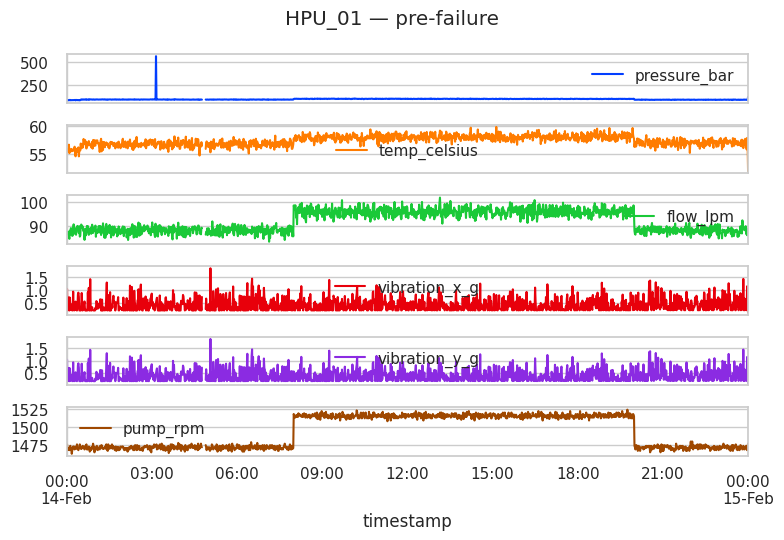

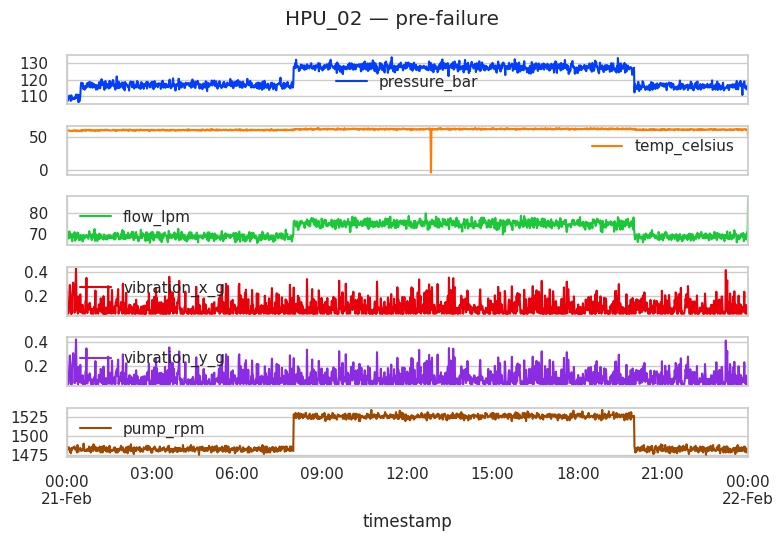

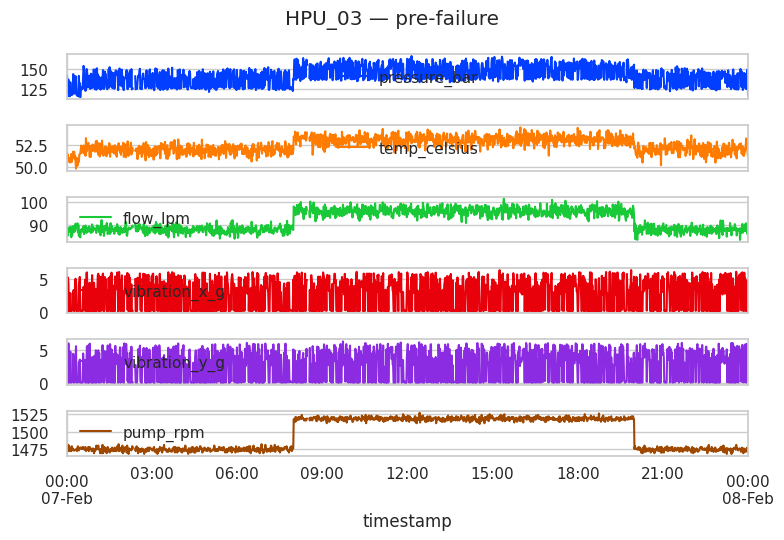

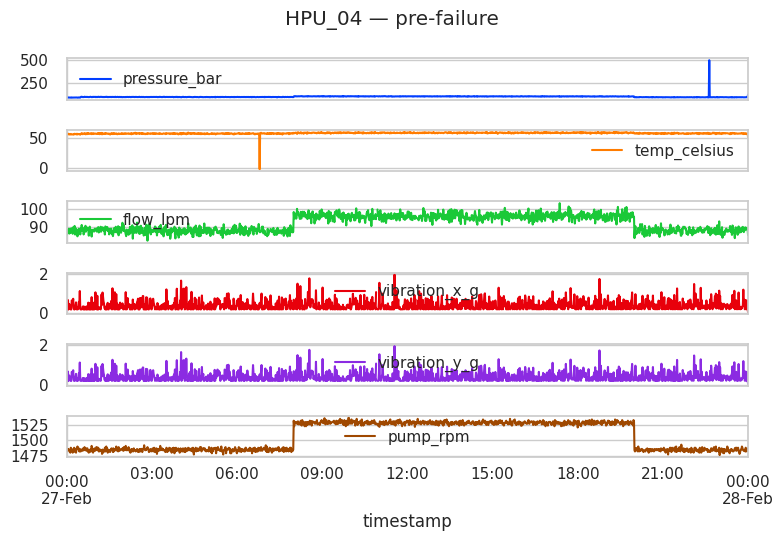

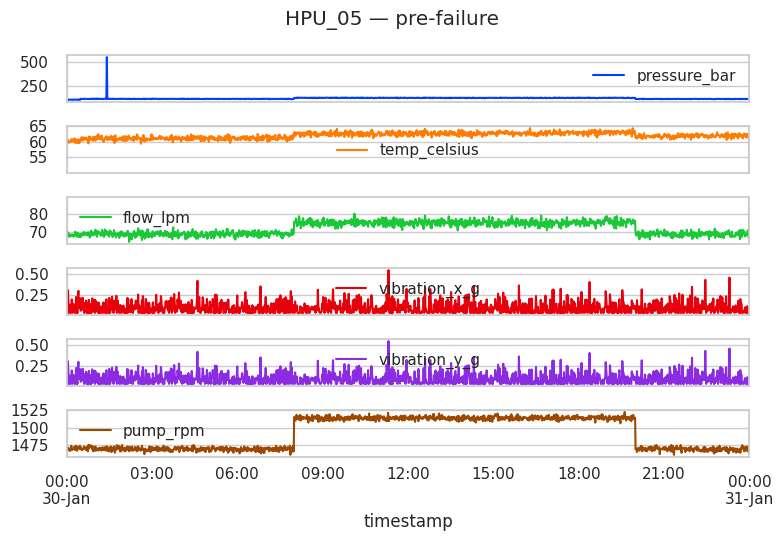

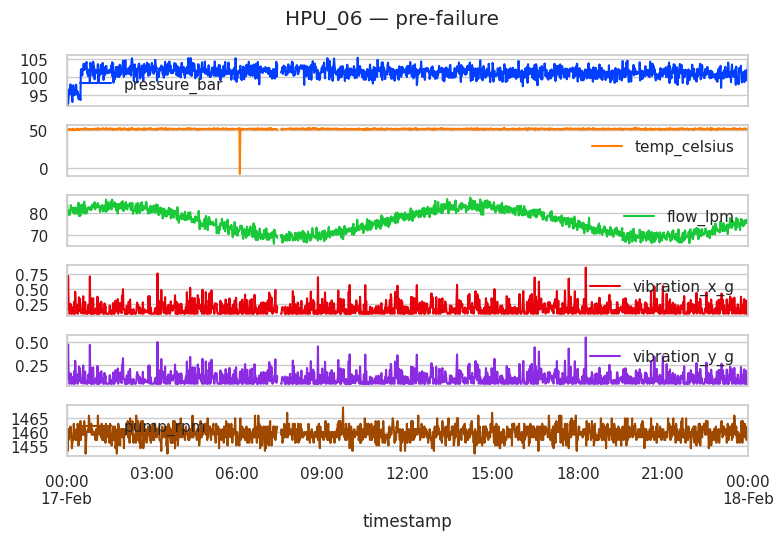

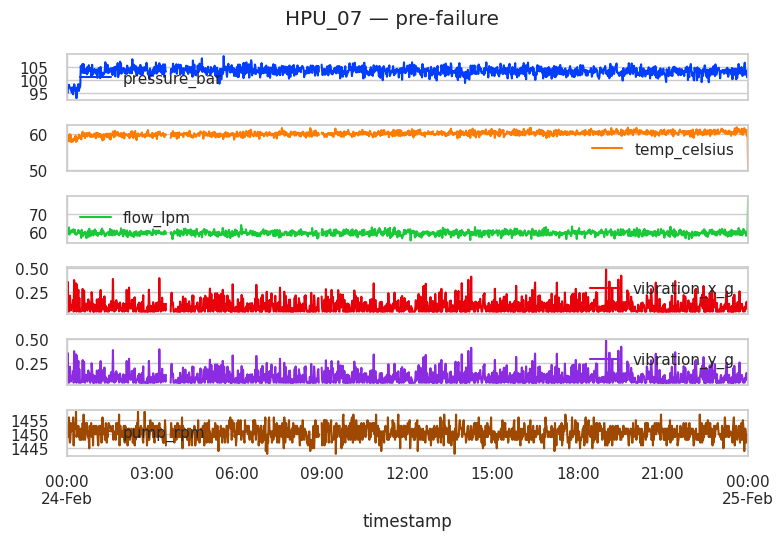

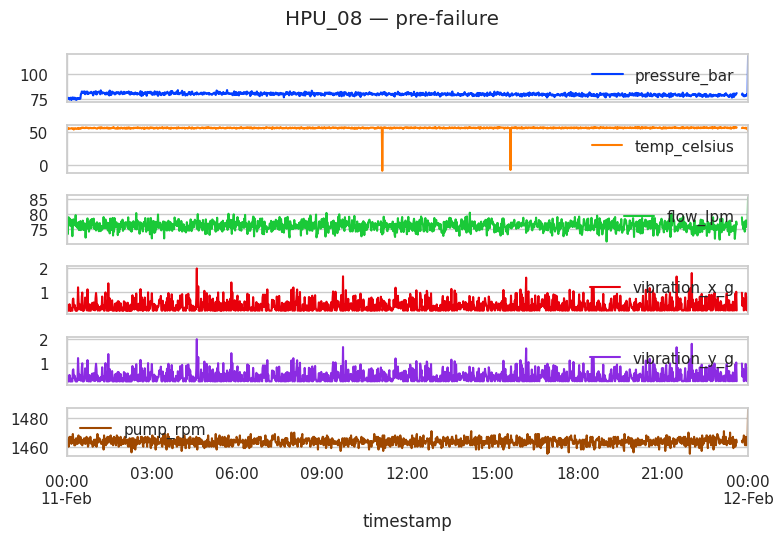

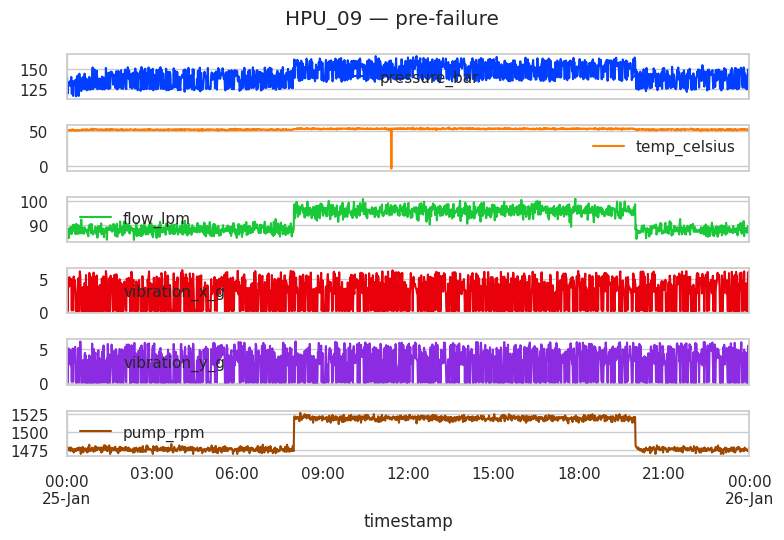

In [185]:
# Anomaly rate by shift and day of week
sensor_df.groupby(['shift', 'day_of_week'])['is_anomaly'].mean().unstack().style.background_gradient()

# Define sensor_cols, which seems to be missing from previous cells.
# Based on context and numerical_cols, these are the likely sensor measurement columns.
sensor_cols = ['pressure_bar', 'temp_celsius', 'flow_lpm', 'vibration_x_g', 'vibration_y_g', 'pump_rpm']

# Sensor trends leading up to failure (look-back window)
# For each failure event, plot the 24h of sensor data before it
# Removed redundant plt.figure(figsize=(8,22)) as DataFrame.plot(subplots=True) creates its own figures.
for idx,row in failure_df.iterrows():
    machine = row['machine_id']
    t_fail  = row['failure_timestamp']
    # Ensure t_fail is a datetime object (already handled by previous cell, but kept for robustness)
    if not pd.api.types.is_datetime64_any_dtype(t_fail):
        t_fail = pd.to_datetime(t_fail)
    window  = sensor_df[
        (sensor_df['machine_id'] == machine) &
        (sensor_df['timestamp'].between(t_fail - pd.Timedelta('24h'), t_fail))
    ]
    # Only plot if the window is not empty
    if not window.empty:
        window.set_index('timestamp')[sensor_cols].plot(subplots=True, title=f"{machine} — pre-failure")
        plt.tight_layout()
        plt.show()
    else:
        print(f"No sensor data found for {machine} in the 24h window before failure at {t_fail}")

##### **Time-based patterns**

In [186]:
sensor_df['machine_id'].value_counts()

,count
machine_id,
HPU_01,86400
HPU_04,86400
HPU_02,86400
HPU_06,86400
HPU_07,86400
HPU_09,86400
HPU_10,86400
HPU_03,86400
HPU_05,86400


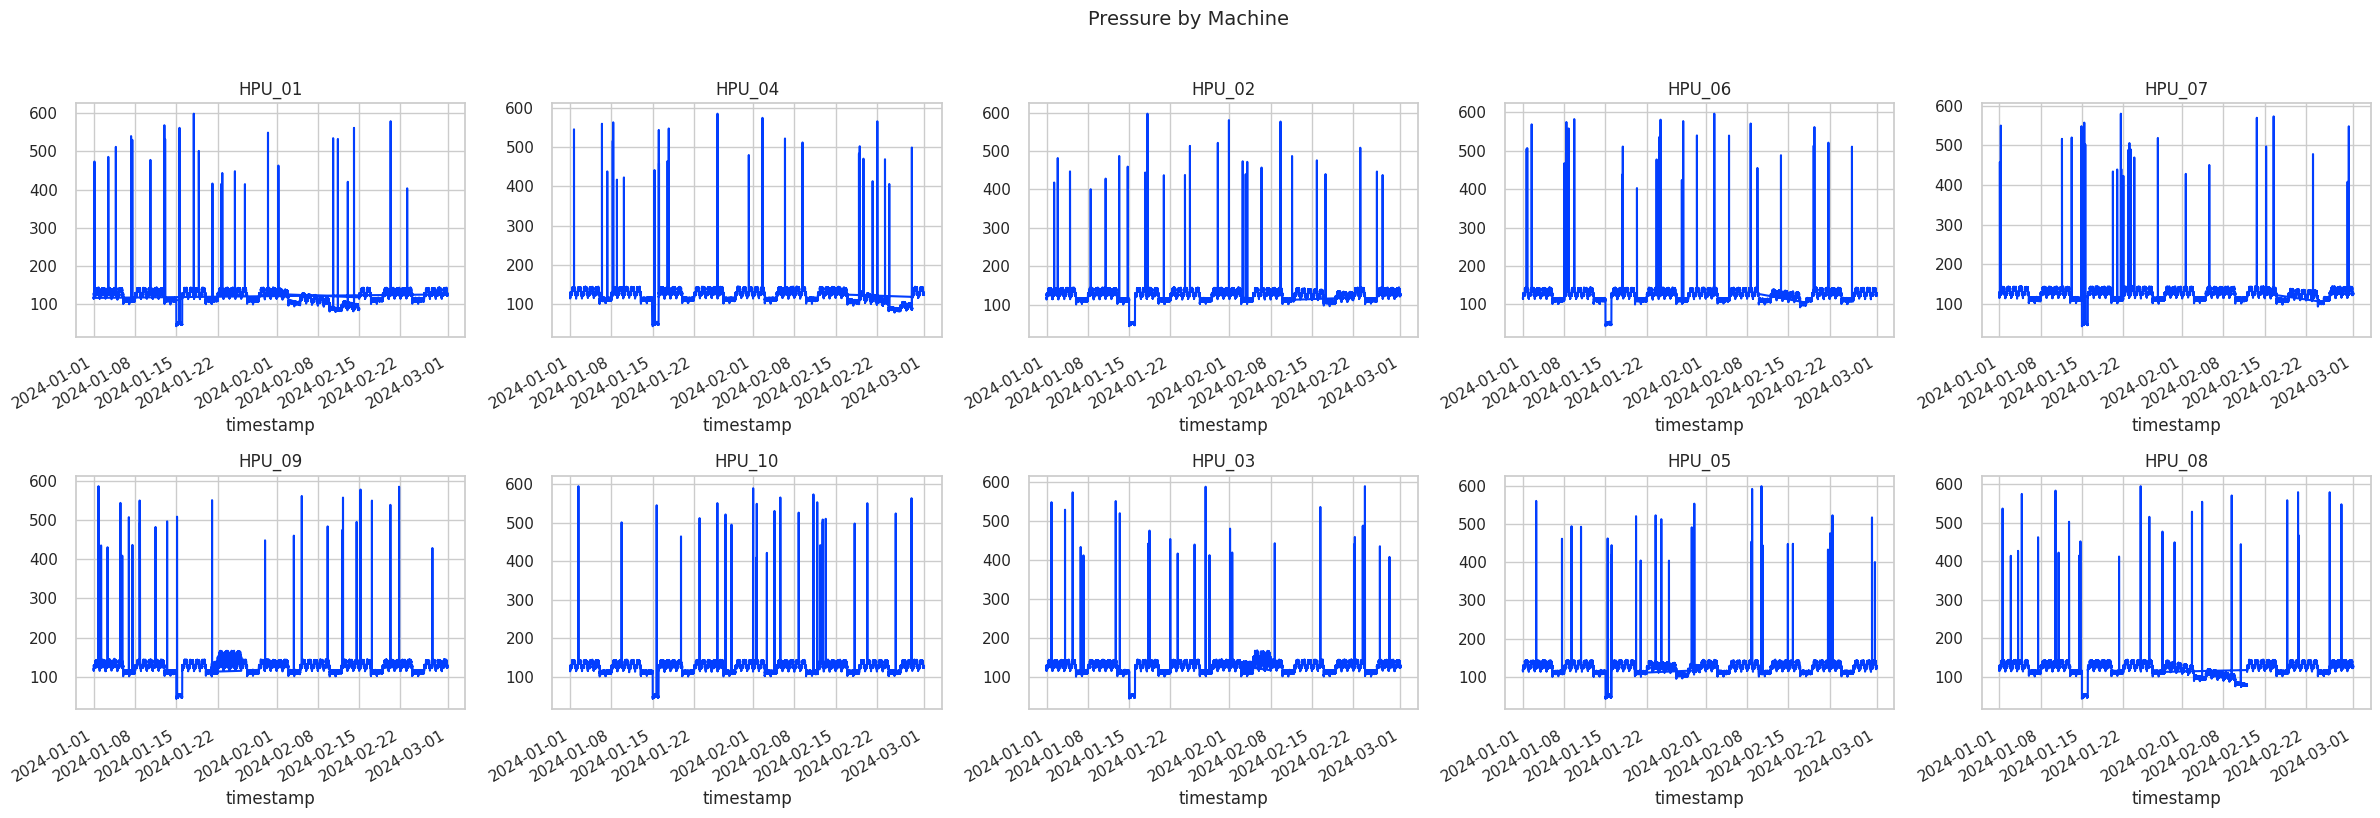

In [187]:
# plot by machine and timestamp
fig, axes = plt.subplots(2, 5, figsize=(24, 8))

for ax, machine in zip(axes.flat, sensor_df['machine_id'].unique()):
    df = sensor_df[sensor_df['machine_id'] == machine]
    df.plot(x='timestamp', y='pressure_bar', ax=ax, legend=False)
    ax.set_title(machine)

plt.suptitle('Pressure by Machine', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Machine-level time-series analysis of hydraulic pressure revealed generally stable baseline operating behavior across the ten hydraulic power units (HPUs), with most machines operating within the expected pressure range of approximately 100–150 bar. However, intermittent extreme pressure spikes and occasional pressure drops were observed across several machines, indicating transient operational instability and potential degradation events. Certain HPUs, including HPU_02 and HPU_08, exhibited more pronounced abnormal pressure behavior, suggesting possible hydraulic inefficiencies or system disturbances. These findings demonstrate that pressure telemetry contains valuable temporal patterns that may support predictive maintenance modeling and early fault detection within the hydraulic systems.

In [188]:
sensor_df['rul_hours'].value_counts().reset_index()

,rul_hours,count
0,500.0,525600
1,0.0,211698
2,74.8,63
3,75.0,63
4,27.4,63
...,...,...
3357,329.3,10
3358,328.5,10
3359,328.7,10
3360,328.3,10


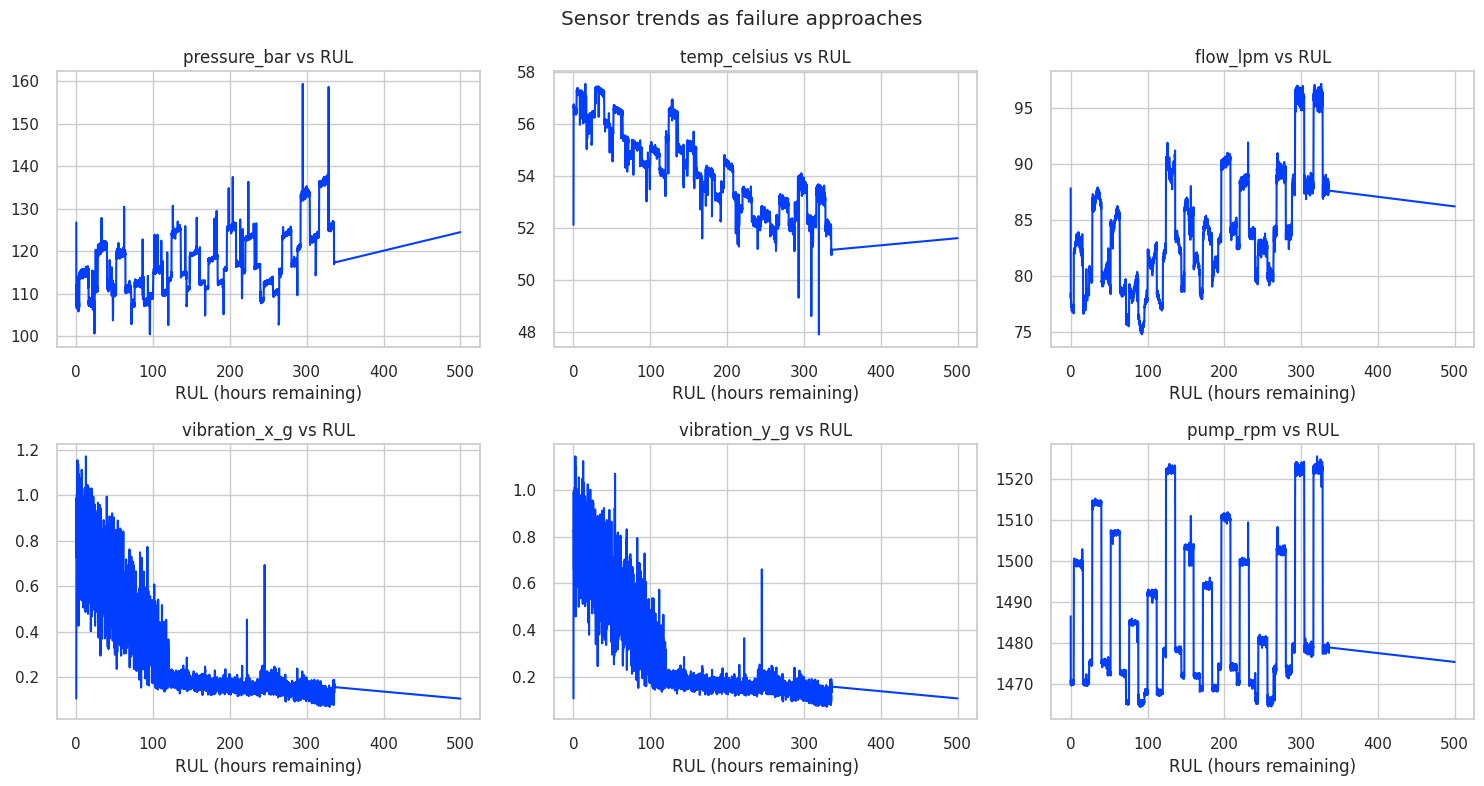

In [189]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flat, sensor_cols):
    sensor_df.groupby('rul_hours')[col].mean().plot(ax=ax)
    ax.set_title(f'{col} vs RUL')
    ax.set_xlabel('RUL (hours remaining)')

plt.suptitle('Sensor trends as failure approaches')
plt.tight_layout()
plt.show()

Analysis of sensor behavior against Remaining Useful Life (RUL) revealed clear degradation patterns as hydraulic systems approached failure. Vibration signals exhibited the strongest relationship with declining RUL, with elevated amplitudes and increasing instability observed near failure events. Pressure and flow rate also demonstrated greater variability and abnormal fluctuations as failure approached, while pump RPM showed increasing operational instability during low-RUL periods. These temporal patterns indicate that the hydraulic telemetry data contains meaningful degradation signatures and early warning indicators suitable for predictive maintenance modeling and Remaining Useful Life estimation.

##### **correlation analysis between all numerical features**

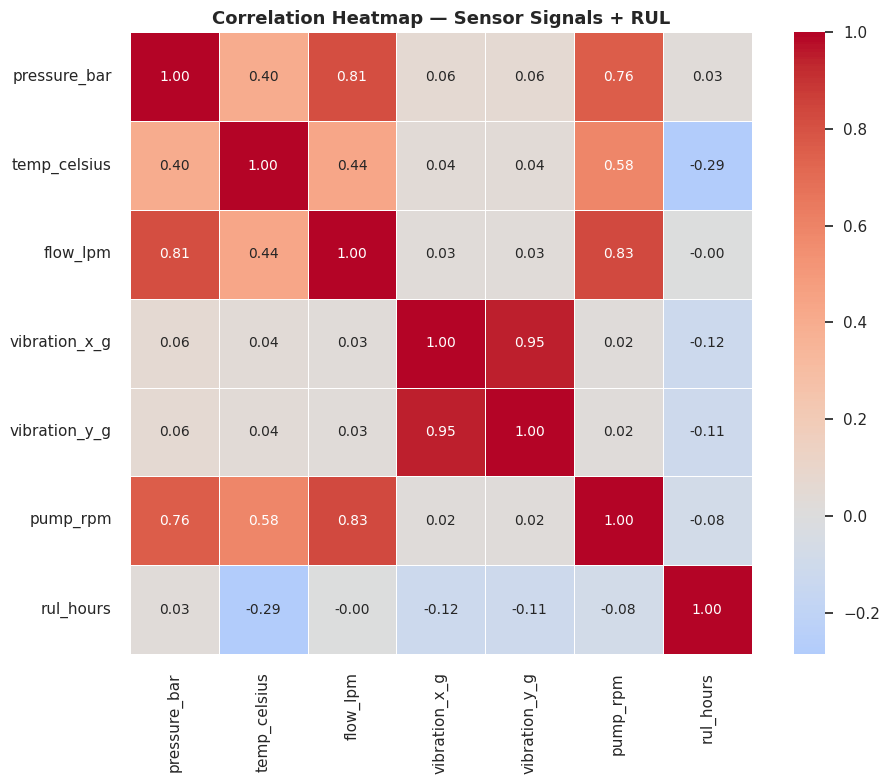

In [190]:
# Correlation of numerical variables
#Correlation matrix of the numerical variables
corr_matrix = sensor_df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True,
            annot_kws={'size': 10})
plt.title('Correlation Heatmap — Sensor Signals + RUL',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##### **Sensor distributions and anomalies**

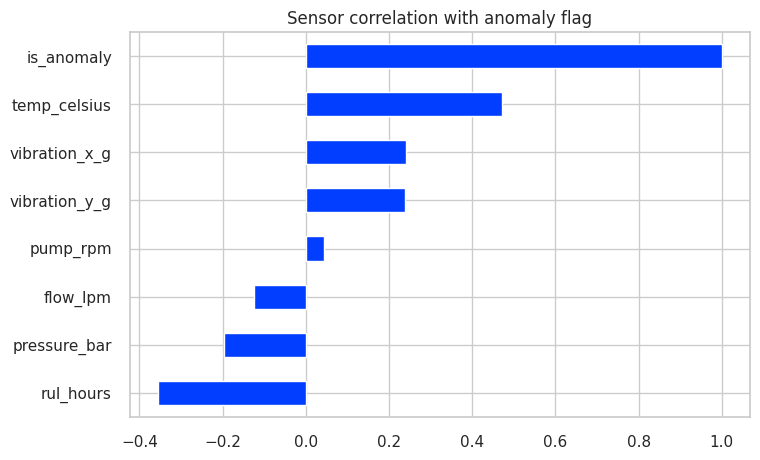

In [191]:
# correlation between sensor readings and anomaly/failure flag
corr_cols = sensor_cols + ['is_anomaly', 'rul_hours']
sensor_df[corr_cols].corr()['is_anomaly'].sort_values().plot(kind='barh', figsize=(8, 5))
plt.title('Sensor correlation with anomaly flag')
plt.show()

Correlation analysis between the hydraulic sensor variables and the anomaly flag revealed that temperature exhibited the strongest positive relationship with anomalous operating conditions, followed by both vibration variables. This suggests that abnormal thermal behavior and increased mechanical instability are strongly associated with degradation and system anomalies. In contrast, pressure and flow rate demonstrated moderate negative correlations, indicating reduced hydraulic performance during abnormal operating states. Remaining Useful Life (RUL) also showed a negative relationship with anomalies, confirming that anomalous behavior becomes more prominent as equipment approaches failure. Overall, the findings indicate that anomaly behavior is influenced by multiple interacting sensor variables, supporting the use of multivariate machine learning approaches for predictive maintenance modeling.

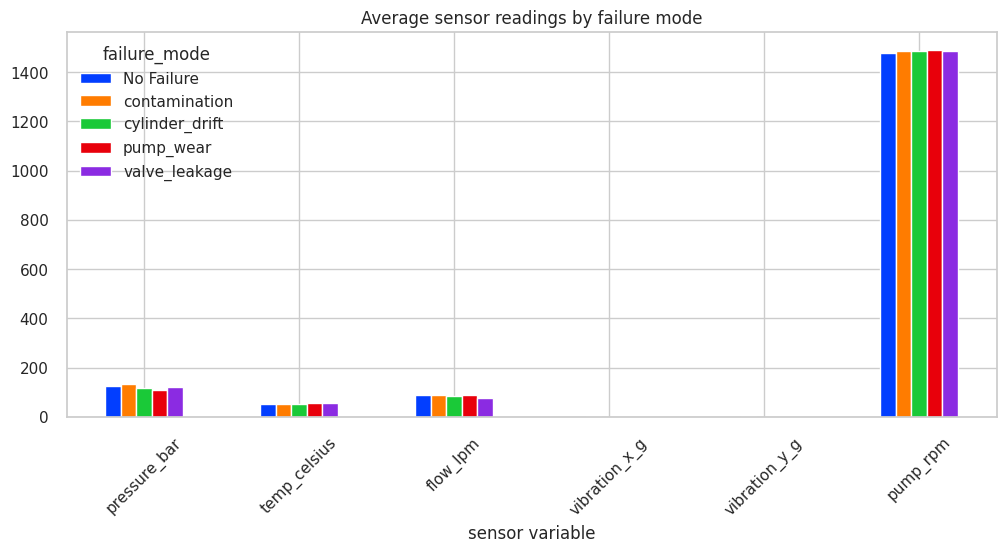

In [192]:
#Failure mode breakdown — which sensors differ per failure type
sensor_df.groupby('failure_mode')[sensor_cols].mean().T.plot(
    kind='bar', figsize=(12, 5)
)
plt.title('Average sensor readings by failure mode')
plt.xlabel('sensor variable')
plt.xticks(rotation=45)
plt.show()

Analysis of average sensor readings across hydraulic failure modes revealed distinct operational patterns associated with different degradation conditions. Pressure and flow rate exhibited the most noticeable variation between failure categories, suggesting that hydraulic performance characteristics are strongly influenced by the underlying fault type. Contamination-related failures showed elevated pressure behavior, while leakage-related conditions demonstrated comparatively lower hydraulic efficiency. Temperature displayed moderate variation across failure modes, whereas pump RPM remained relatively stable under most conditions. Although average vibration differences appeared limited in the aggregated analysis, previous time-series investigations indicated that vibration instability and transient spikes remain important indicators of mechanical degradation. Overall, the results confirm that the telemetry data contains meaningful multi-sensor signatures suitable for failure mode classification and predictive maintenance modeling.

In [193]:
sensor_df.groupby(['machine_id'])['is_anomaly'].mean().reset_index()

,machine_id,is_anomaly
0,HPU_01,0.233333
1,HPU_02,0.166667
2,HPU_03,0.083333
3,HPU_04,0.200000
4,HPU_05,0.166667
5,HPU_06,0.133333
6,HPU_07,0.166667
7,HPU_08,0.233333
8,HPU_09,0.083333
9,HPU_10,0.000000


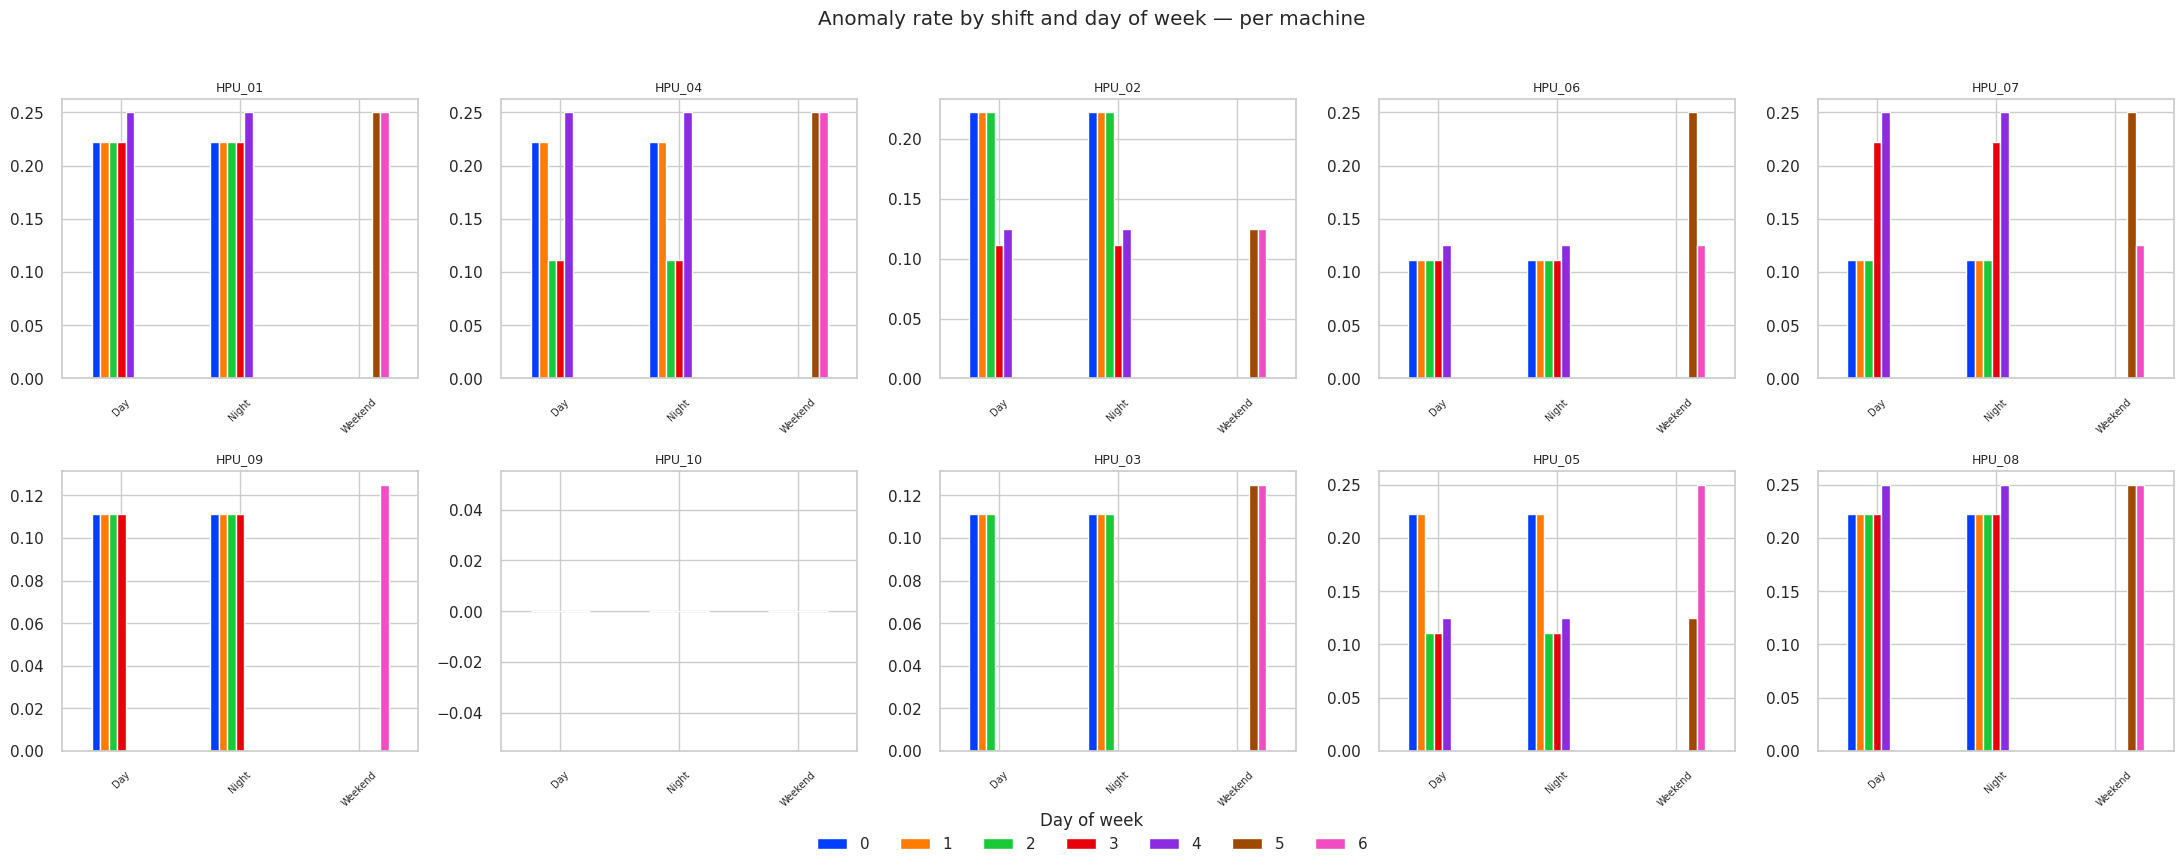

In [194]:
#Anomaly rate by shift and day of week — per machine
fig, axes = plt.subplots(2, 5, figsize=(22, 8))

for ax, machine in zip(axes.flat, sensor_df['machine_id'].unique()):
    machine_data = sensor_df[sensor_df['machine_id'] == machine]
    machine_data.groupby(['shift', 'day_of_week'])['is_anomaly'].mean().unstack().plot(kind='bar', ax=ax, legend=False)
    ax.set_title(machine, fontsize=9)
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=7)

# Single shared legend
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Day of week', loc='lower center',
           ncol=7, bbox_to_anchor=(0.5, -0.05))

plt.suptitle('Anomaly rate by shift and day of week — per machine', y=1.02)
plt.tight_layout()
plt.show()

This visualization provides a machine-level view of anomaly behavior across operational shifts and days of the week, revealing that anomaly occurrence varies noticeably between hydraulic units and operational periods. Several machines, including HPU_01, HPU_04, HPU_07, and HPU_08, exhibit consistently higher anomaly rates across both Day and Night shifts, suggesting persistent operational stress or recurring degradation patterns within those hydraulic units. In contrast, machines such as HPU_03, HPU_06, and HPU_09 show comparatively lower anomaly frequencies, indicating more stable operational behavior.

The analysis also suggests that anomaly patterns differ across weekdays and weekends. For some machines, particularly HPU_04, HPU_05, and HPU_07, anomaly rates appear elevated during Weekend operations, which may reflect irregular operating schedules, maintenance activities, startup/shutdown cycles, or reduced operational stability during non-peak production periods. Additionally, the variation in anomaly behavior across machines indicates that degradation patterns are machine-specific rather than uniform across the fleet, reinforcing the importance of machine-level predictive maintenance monitoring and individualized failure modeling. HPU_10 is actually very different from the other hydraulic units in the visualization.

Unlike the other machines, HPU_10 shows almost no visible anomaly activity across all shifts and days of the week. The subplot appears nearly empty, indicating that anomaly rates are extremely low or absent, the machine experienced little to no abnormal operating behavior during the observation period, and HPU_10 operated under highly stable conditions compared to the rest of the fleet.

This could suggest several possibilities:

- HPU_10 is one of the healthiest and most stable hydraulic systems,
- it may have operated under lighter workloads,
- it may have undergone recent maintenance,
- it experienced fewer degradation events during the monitoring period.

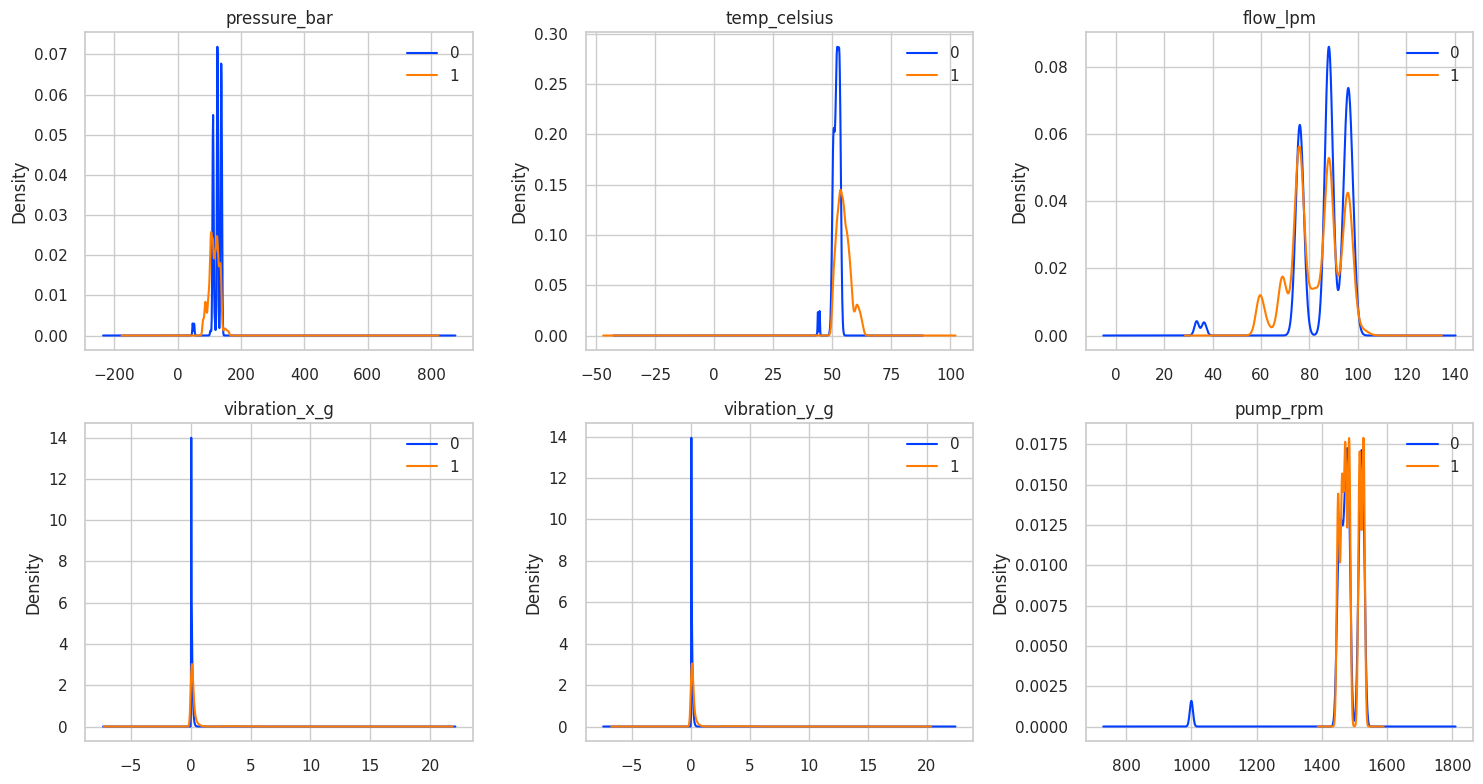

In [195]:
# Distributions split by anomaly label
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, sensor_cols):
    sensor_df.groupby('is_anomaly')[col].plot.kde(ax=ax, legend=True)
    ax.set_title(col)
plt.tight_layout()

Density-based comparison of sensor distributions between normal and anomalous operating states revealed noticeable behavioral differences across several hydraulic telemetry variables. Flow rate and pump RPM exhibited the clearest class separation, while temperature and vibration signals showed increased variability and broader distributions under anomalous conditions. Although significant overlap existed between the classes, the anomaly group generally demonstrated greater dispersion and instability across multiple sensors. These findings suggest that predictive maintenance modeling will benefit from multi-sensor temporal feature engineering rather than relying solely on single-variable thresholds, reflecting the complex and gradual nature of industrial equipment degradation.

##### **failure_mode analysis**

In [196]:
#distribution of failure mode
sensor_df['failure_mode'].value_counts().reset_index()

,failure_mode,count
0,No Failure,737280
1,pump_wear,57600
2,valve_leakage,43200
3,contamination,14400
4,cylinder_drift,11520


In [197]:
# Sensor behavior by failure mode (are anomaly readings predictive?)
sensor_df.groupby('failure_mode')[sensor_cols].mean().reset_index()

,failure_mode,pressure_bar,temp_celsius,flow_lpm,vibration_x_g,vibration_y_g,pump_rpm
0,No Failure,125.099322,51.772784,86.702824,0.106935,0.106926,1478.487113
1,contamination,132.176718,51.865130,87.185428,1.634783,1.636857,1483.826974
2,cylinder_drift,118.051292,51.866887,86.029966,0.137317,0.105757,1486.992932
3,pump_wear,107.119610,54.473373,87.194877,0.264524,0.264447,1489.100399
4,valve_leakage,121.525309,57.032915,74.905523,0.106593,0.106593,1485.079816


In [198]:
# RUL distribution — how much life remains at time of anomaly?
sensor_df[sensor_df['is_anomaly'] == 1]['rul_hours'].describe()

,rul_hours
count,126720.000000
mean,129.553788
std,84.676052
min,0.000000
25%,58.700000
50%,117.300000
75%,192.000000
max,336.000000


In [199]:
sensor_df['failure_mode'].value_counts(normalize=True).reset_index() * 100

,failure_mode,proportion
0,No FailureNo FailureNo FailureNo FailureNo Fai...,85.333333
1,pump_wearpump_wearpump_wearpump_wearpump_wearp...,6.666667
2,valve_leakagevalve_leakagevalve_leakagevalve_l...,5.000000
3,contaminationcontaminationcontaminationcontami...,1.666667
4,cylinder_driftcylinder_driftcylinder_driftcyli...,1.333333


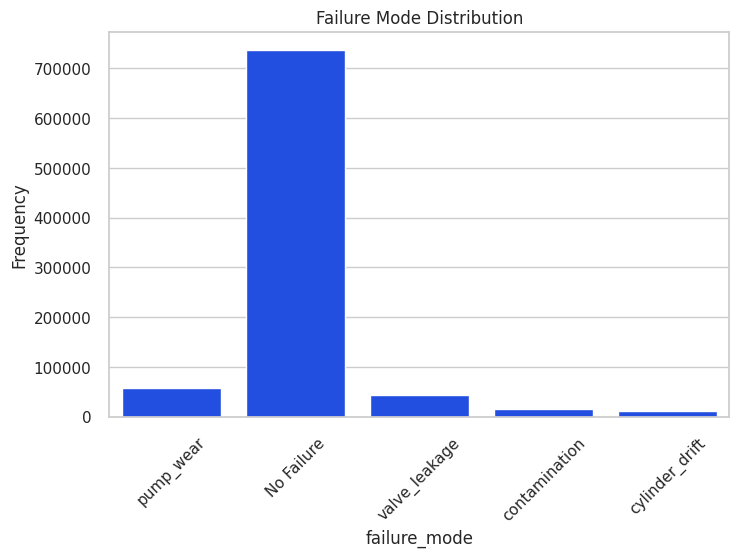

In [200]:
plt.figure(figsize=(8,5))
sns.countplot(x='failure_mode', data = sensor_df)
plt.xlabel('failure_mode')
plt.xticks(rotation=45)
plt.ylabel('Frequency')
plt.title('Failure Mode Distribution')
plt.show()

The failure mode distribution revealed noticeable class imbalance across operational states, with certain failure categories occurring significantly less frequently than others. This imbalance is expected in predictive maintenance environments, where actual equipment failures are relatively rare compared to normal operating conditions. The observation highlights the potential need for imbalance handling techniques during machine learning model development.

##### **Binary Anomaly Distribution**

In [201]:
sensor_df['is_anomaly'].value_counts().reset_index()

,is_anomaly,count
0,0,737280
1,1,126720


The anomaly distribution analysis revealed that the majority of telemetry observations corresponded to normal operating conditions, while a substantial proportion of records were labeled as anomalous. This indicates that the hydraulic systems experience recurring abnormal operational behavior rather than isolated rare events. Although the dataset exhibits moderate class imbalance, the anomaly class remains sufficiently represented to support supervised machine learning applications for predictive maintenance. The presence of meaningful anomalous behavior suggests that the telemetry data contains detectable degradation and instability patterns that may serve as early warning indicators for hydraulic system failure.

In [202]:
#Anomaly frequency by shift
anomaly_by_shift = (
    sensor_df.groupby('shift')['is_anomaly']
    .agg(['count', 'sum', 'mean'])
    .reset_index()
)

anomaly_by_shift.columns = [
    'shift',
    'total_records',
    'anomaly_count',
    'anomaly_rate'
]

anomaly_by_shift

,shift,total_records,anomaly_count,anomaly_rate
0,Day,316800,44640,0.140909
1,Night,316800,44640,0.140909
2,Weekend,230400,37440,0.162500


The exploratory data analysis revealed that the hydraulic systems generally operate under stable conditions, with pressure, temperature, flow rate, and pump RPM remaining within controlled operational ranges during normal machine activity. However, several sensor variables, particularly pressure and vibration, exhibited intermittent spikes, instability, and outlier behavior, indicating abnormal operating conditions and potential degradation events. Time-series analysis also showed synchronized anomalies across multiple sensors, suggesting system-level disturbances rather than isolated sensor irregularities.

Further analysis demonstrated that machine behavior varies across operational shifts and failure modes. The Day shift experienced the highest operational workload, while Weekend operations showed slightly elevated anomaly rates despite lower utilization. Correlation and RUL analyses revealed that temperature and vibration variables are strongly associated with anomalies and degradation progression, with sensor instability increasing significantly as failure approaches. Overall, the dataset contains rich temporal and operational patterns suitable for predictive maintenance, anomaly detection, failure classification, and Remaining Useful Life (RUL) prediction.

#### **DATA CLEANING AND PREPARATION**

This task focuses on transforming raw industrial sensor data into a clean, structured, and machine learning–ready dataset. Real-world hydraulic data often contains missing values, noise, inconsistencies, and outliers due to sensor malfunction or environmental conditions. The goal is to apply systematic cleaning techniques to ensure data reliability, consistency, and correctness before modeling begins.
##### **Task**
- Identify and handle missing values:
  - Forward/backward filling
  - Interpolation for time-series gaps
- Remove duplicate records
- Correct inconsistent data formats
- Detect and handle outliers in sensor signals
- Smooth noisy time-series data where necessary
- Ensure correct timestamp ordering and continuity
- Validate data consistency across all features
- Produce finalized cleaned dataset for feature engineering

##### **Merging all four datasets**

In [203]:
#merging equiment dataset to sensor dataset
merged_df = sensor_df.merge(equipment_df, on='machine_id', how='left')
merged_df.shape

(864000, 19)

In [204]:
# sort merged_df and maintenance_df before merge_asof
merged_df = merged_df.sort_values(['machine_id', 'timestamp']).reset_index(drop=True)
maintenance_df = maintenance_df.sort_values(['machine_id', 'action_timestamp']).reset_index(drop=True)

In [205]:
# checking dtypes
print(merged_df['timestamp'].dtype)
print(maintenance_df['action_timestamp'].dtype)

# checking for nulls
print("merged_df null timestamps:", merged_df['timestamp'].isna().sum())
print("maintenance_df null timestamps:", maintenance_df['action_timestamp'].isna().sum())

# checking if sorted within each machine group
print("merged_df sorted:", merged_df.groupby('machine_id')['timestamp'].is_monotonic_increasing.all())
print("maintenance_df sorted:", maintenance_df.groupby('machine_id')['action_timestamp'].is_monotonic_increasing.all())

datetime64[ns]
datetime64[ns]
merged_df null timestamps: 0
maintenance_df null timestamps: 0
merged_df sorted: True
maintenance_df sorted: True


In [206]:
# Sort by timestamp only (not by machine_id first)
merged_df = merged_df.sort_values('timestamp').reset_index(drop=True)
maintenance_df = maintenance_df.sort_values('action_timestamp').reset_index(drop=True)

merged_sensor_df = pd.merge_asof(
    merged_df,
    maintenance_df,
    left_on='timestamp',
    right_on='action_timestamp',
    by='machine_id',
    direction='backward'
)

print(merged_sensor_df.shape)

(864000, 25)


In [207]:
# sorting again and merging failure_df
failure_df = failure_df.sort_values('failure_timestamp').reset_index(drop=True)

full_df = pd.merge_asof(
    merged_df,
    failure_df,
    left_on='timestamp',
    right_on='failure_timestamp',
    by='machine_id',
    direction='backward'
)

# verifying the dimension after merging
print(full_df.shape)

(864000, 25)


In [208]:
full_df.head()

,timestamp,machine_id,pressure_bar,temp_celsius,flow_lpm,vibration_x_g,vibration_y_g,pump_rpm,is_anomaly,failure_mode_x,...,total_operating_hours,fluid_type,last_filter_change_date,maintenance_priority,failure_event_id,failure_timestamp,failure_mode_y,degradation_start_timestamp,repair_cost_usd,downtime_hours
0,2024-01-01,HPU_01,116.99,50.84,88.97,0.2930,0.2930,1473.0,0,No Failure,...,14012,mineral_oil,2023-12-19,Low,NaN,NaT,NaN,NaT,NaN,NaN
1,2024-01-01,HPU_04,117.47,51.02,86.89,0.1736,0.1736,1485.0,0,No Failure,...,5976,mineral_oil,2023-12-18,High,NaN,NaT,NaN,NaT,NaN,NaN
2,2024-01-01,HPU_06,115.47,50.08,91.33,0.0505,0.0505,1483.0,0,No Failure,...,5869,mineral_oil,2023-10-06,High,NaN,NaT,NaN,NaT,NaN,NaN
3,2024-01-01,HPU_03,116.93,50.68,90.07,0.1050,0.1050,1477.0,0,No Failure,...,7848,mineral_oil,2023-10-14,Low,NaN,NaT,NaN,NaT,NaN,NaN
4,2024-01-01,HPU_07,118.24,50.43,88.05,0.2488,0.2488,1469.0,0,No Failure,...,18746,synthetic,2023-10-14,Medium,NaN,NaT,NaN,NaT,NaN,NaN


In [209]:
# after merging the four datasets, we check the data quality of the dataset and save a sample of 100 rows of the data
sample_full_df = full_df.sample(n=100, random_state=42)
sample_full_df.head()
sample_full_df.to_csv("/content/drive/MyDrive/predictive maintenance project/sample_full_df.csv", index=False)

## Filtering down to is_anomaly=1

In [210]:
# Filter to anomaly rows only
model_df = full_df[full_df['is_anomaly'] == 1].copy()
model_df = model_df.sort_values(
    ['machine_id', 'timestamp']
).reset_index(drop=True)

print("Filtering dataset to is_anomaly=1 only\n")
print(f"Shape: {model_df.shape}")
print(f"Machines: {model_df['machine_id'].nunique()}")
print(f"Unique machines: {sorted(model_df['machine_id'].unique())}")

print(f"\nRUL Distribution:")
print(f"Mean: {model_df['rul_hours'].mean():.2f} hours")
print(f"Std: {model_df['rul_hours'].std():.2f} hours")
print(f"Min: {model_df['rul_hours'].min():.2f} hours")
print(f"Max: {model_df['rul_hours'].max():.2f} hours")
print(f"Median: {model_df['rul_hours'].median():.2f} hours")

print(f"\nRows per machine:")
print(model_df['machine_id'].value_counts().sort_index())

Filtering dataset to is_anomaly=1 only

Shape: (126720, 25)
Machines: 9
Unique machines: ['HPU_01', 'HPU_02', 'HPU_03', 'HPU_04', 'HPU_05', 'HPU_06', 'HPU_07', 'HPU_08', 'HPU_09']

RUL Distribution:
Mean: 129.55 hours
Std: 84.68 hours
Min: 0.00 hours
Max: 336.00 hours
Median: 117.30 hours

Rows per machine:
machine_id
HPU_01    20160
HPU_02    14400
HPU_03     7200
HPU_04    17280
HPU_05    14400
HPU_06    11520
HPU_07    14400
HPU_08    20160
HPU_09     7200
Name: count, dtype: int64


## Investigating missing values in the filtered dataset

In [211]:
print("Investigating missing Values in Filtered Dataset\n")

missing= model_df.isnull().sum()
missing_pct = (missing / len(model_df) * 100).round(2)

summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct,
    'Dtype': model_df.dtypes
})

# Show all columns regardless of missing count
print(f"{'Column':<35} {'Missing Count':<20} {'Missing %':<15} {'Dtype'}")
print(f"{'_'*80}")
for col in summary.index:
    # Corrected conditional assignment for 'flag'
    flag = " *Missing" if summary.loc[col, 'Missing Count'] > 0 else ""
    print(f"   {col:<35} {summary.loc[col,'Missing Count']:<20,} "
          f"{summary.loc[col,'Missing %']:<15}{summary.loc[col,'Dtype']}{flag}")

Investigating missing Values in Filtered Dataset

Column                              Missing Count        Missing %       Dtype
________________________________________________________________________________
   timestamp                           0                    0.0            datetime64[ns]
   machine_id                          0                    0.0            object
   pressure_bar                        398                  0.31           float64 *Missing
   temp_celsius                        398                  0.31           float64 *Missing
   flow_lpm                            398                  0.31           float64 *Missing
   vibration_x_g                       398                  0.31           float64 *Missing
   vibration_y_g                       398                  0.31           float64 *Missing
   pump_rpm                            398                  0.31           float64 *Missing
   is_anomaly                          0                    0.0   

## Dropping columns with 100% missing values

In [212]:
# Drop columns with 100% missing values
drop_cols = [
    'failure_event_id',
    'failure_timestamp',
    'failure_mode_y',
    'degradation_start_timestamp',
    'repair_cost_usd',
    'downtime_hours'
]

model_df = model_df.drop(columns=drop_cols)

print("Dropped 100% missing columns\n")
print(f"Columns dropped: {drop_cols}")
print(f"New shape: {model_df.shape}")

Dropped 100% missing columns

Columns dropped: ['failure_event_id', 'failure_timestamp', 'failure_mode_y', 'degradation_start_timestamp', 'repair_cost_usd', 'downtime_hours']
New shape: (126720, 19)


## Filling the missing values with interpolation

In [213]:
# Sort first
model_df = model_df.sort_values(
    ['machine_id', 'timestamp']
).reset_index(drop=True)

# Linear interpolation per machine
model_df[sensor_cols] = (
    model_df.groupby('machine_id')[sensor_cols]
    .transform(lambda x: x.interpolate(
        method='linear',
        limit_direction='both'
    ))
)

# Verify
model_df[sensor_cols].isnull().sum()


,0
pressure_bar,0
temp_celsius,0
flow_lpm,0
vibration_x_g,0
vibration_y_g,0
pump_rpm,0


#### **FEATURE ENGINEERING**
This task involves transforming raw sensor signals into meaningful engineered features that improve the predictive power of machine learning models. Since hydraulic systems generate continuous time-series data, it is important to extract temporal, statistical, and behavioral patterns that represent system degradation over time. These features help capture early warning signs of failure and improve model interpretability.

##### **Task**
- Create rolling window features:
  - Rolling mean
  - Rolling standard deviation
  - Rolling minimum and maximum
- Generate lag features to capture temporal dependencies
- Compute trend-based features (rate of change over time)
- Extract vibration-based features for mechanical wear detection
- Aggregate sensor behavior over defined time windows
- Normalize or scale features if required
- Prepare final feature matrix for modeling

## Engineering rate of change from each sensor feature

In [214]:
# Define sensor columns
sensor_cols = ['pressure_bar', 'temp_celsius', 'flow_lpm',
               'vibration_x_g', 'vibration_y_g', 'pump_rpm']

for col in sensor_cols:
    model_df[f'{col}_delta'] = (
        model_df.groupby('machine_id')[col]
        .diff()
        .fillna(0)
    )

delta_cols = [f'{col}_delta' for col in sensor_cols]

print("Delta features created\n")
print(f"Total delta features : {len(delta_cols)}")
for col in delta_cols:
    print(f"{col}")

Delta features created

Total delta features : 6
pressure_bar_delta
temp_celsius_delta
flow_lpm_delta
vibration_x_g_delta
vibration_y_g_delta
pump_rpm_delta


## Engineering lag features

In [215]:
# Engineering lag features
lag_steps = [1, 3, 6]

for col in sensor_cols:
    for lag in lag_steps:
        model_df[f'{col}_lag{lag}'] = (
            model_df.groupby('machine_id')[col]
            .shift(lag)
            .fillna(method='bfill')
        )

lag_cols = [f'{col}_lag{lag}' for col in sensor_cols
                               for lag in lag_steps]

print("Lag features created\n")
print(f"Total lag features: {len(lag_cols)}")
for col in lag_cols:
    print(f"{col}")

Lag features created

Total lag features: 18
pressure_bar_lag1
pressure_bar_lag3
pressure_bar_lag6
temp_celsius_lag1
temp_celsius_lag3
temp_celsius_lag6
flow_lpm_lag1
flow_lpm_lag3
flow_lpm_lag6
vibration_x_g_lag1
vibration_x_g_lag3
vibration_x_g_lag6
vibration_y_g_lag1
vibration_y_g_lag3
vibration_y_g_lag6
pump_rpm_lag1
pump_rpm_lag3
pump_rpm_lag6


## Rolling windows features

In [216]:
WINDOW = 15

for col in sensor_cols:
    grouped = model_df.groupby('machine_id')[col]

    model_df[f'{col}_roll_mean_15m'] = grouped.transform(
        lambda x: x.rolling(WINDOW, min_periods=1).mean())

rolling_cols = [f'{col}_{stat}_15m'
                for col in sensor_cols
                for stat in ['roll_mean', 'roll_std',
                             'roll_min', 'roll_max']]

print("Rolling window features created (window=15 mins)\n")
print(f"Total rolling features: {len(rolling_cols)}\n")
for col in rolling_cols:
    print(f"{col}")

Rolling window features created (window=15 mins)

Total rolling features: 24

pressure_bar_roll_mean_15m
pressure_bar_roll_std_15m
pressure_bar_roll_min_15m
pressure_bar_roll_max_15m
temp_celsius_roll_mean_15m
temp_celsius_roll_std_15m
temp_celsius_roll_min_15m
temp_celsius_roll_max_15m
flow_lpm_roll_mean_15m
flow_lpm_roll_std_15m
flow_lpm_roll_min_15m
flow_lpm_roll_max_15m
vibration_x_g_roll_mean_15m
vibration_x_g_roll_std_15m
vibration_x_g_roll_min_15m
vibration_x_g_roll_max_15m
vibration_y_g_roll_mean_15m
vibration_y_g_roll_std_15m
vibration_y_g_roll_min_15m
vibration_y_g_roll_max_15m
pump_rpm_roll_mean_15m
pump_rpm_roll_std_15m
pump_rpm_roll_min_15m
pump_rpm_roll_max_15m


## Sensor interactive features

In [217]:
# Vibration Magnitude for combined mechanical stress
model_df['vibration_magnitude'] = np.sqrt(
    model_df['vibration_x_g']**2 + model_df['vibration_y_g']**2
)

# Hydraulic Power i.e pressure × flow
model_df['hydraulic_power'] = (
    model_df['pressure_bar'] * model_df['flow_lpm']
)

# Flow Efficiency i.e flow delivered per RPM
model_df['flow_efficiency'] = (
    model_df['flow_lpm'] / model_df['pump_rpm'].replace(0, np.nan)
).fillna(0)

# Pressure per RPM for pressure generated per revolution
model_df['pressure_per_rpm'] = (
    model_df['pressure_bar'] / model_df['pump_rpm'].replace(0, np.nan)
).fillna(0)

# Thermal Stress Index i.e heat × vibration combined stress
model_df['thermal_stress_index'] = (
    model_df['temp_celsius'] * model_df['vibration_magnitude']
)

# Vibration to Flow Ratio i.e cavitation risk indicator
model_df['vibration_flow_ratio'] = (
    model_df['vibration_magnitude'] / model_df['flow_lpm'].replace(0, np.nan)
).fillna(0)

# Pump Efficiency Index for overall pump health
model_df['pump_efficiency_index'] = (
    (model_df['flow_lpm'] * model_df['pressure_bar']) /
    model_df['pump_rpm'].replace(0, np.nan)
).fillna(0)

# Pressure Temperature Ratio i.e the fluid/cooling health
model_df['pressure_temp_ratio'] = (
    model_df['pressure_bar'] / model_df['temp_celsius'].replace(0, np.nan)
).fillna(0)

interaction_cols = [
    'vibration_magnitude',
    'hydraulic_power',
    'flow_efficiency',
    'pressure_per_rpm',
    'thermal_stress_index',
    'vibration_flow_ratio',
    'pump_efficiency_index',
    'pressure_temp_ratio'
]

print("interaction features created\n")
print(f"Total interaction features : {len(interaction_cols)}")
for col in interaction_cols:
    print(f"{col:<30} "
          f"mean={model_df[col].mean():.4f}  "
          f"std={model_df[col].std():.4f}")

interaction features created

Total interaction features : 8
vibration_magnitude            mean=0.5035  std=1.2258
hydraulic_power                mean=9666.3310  std=2167.0882
flow_efficiency                mean=0.0557  std=0.0064
pressure_per_rpm               mean=0.0778  std=0.0106
thermal_stress_index           mean=26.9973  std=64.0923
vibration_flow_ratio           mean=0.0058  std=0.0138
pump_efficiency_index          mean=6.4830  std=1.3692
pressure_temp_ratio            mean=2.1057  std=1.2681


## Equipment based features

In [218]:
# Machine age in days at time of reading
model_df['machine_age_days'] = (
    model_df['timestamp'] - model_df['installation_date']
).dt.days

# Days since last filter change
model_df['days_since_filter_change'] = (
    model_df['timestamp'] - model_df['last_filter_change_date']
).dt.days

equipment_cols = [
    'machine_age_days',
    'days_since_filter_change'
]

print("Equipment-based features created\n")
for col in equipment_cols:
    print(f"{col:<30} "
          f"mean={model_df[col].mean():.2f}  "
          f"min={model_df[col].min()}  "
          f"max={model_df[col].max()}")

Equipment-based features created

machine_age_days               mean=463.52  min=295  max=744
days_since_filter_change       mean=84.47  min=30  max=134


## Encoding the categorical variables

In [219]:
from sklearn.preprocessing import LabelEncoder

# shift
le_shift = LabelEncoder()
model_df['shift'] = le_shift.fit_transform(model_df['shift'])

shift_mapping = dict(zip(le_shift.classes_,
                         le_shift.transform(le_shift.classes_)))

# fluid_type
le_fluid = LabelEncoder()
model_df['fluid_type'] = le_fluid.fit_transform(model_df['fluid_type'])

fluid_mapping = dict(zip(le_fluid.classes_,
                         le_fluid.transform(le_fluid.classes_)))

# maintenance_priority
priority_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
model_df['maintenance_priority'] = (
    model_df['maintenance_priority'].map(priority_mapping)
)

# failure_mode_x
le_failure = LabelEncoder()
model_df['failure_mode_x'] = le_failure.fit_transform(model_df['failure_mode_x'])

failure_mapping = dict(zip(le_failure.classes_,
                           le_failure.transform(le_failure.classes_)))

print("Categorical features encoded\n")
print(f"shift mapping: {shift_mapping}")
print(f"fluid_type mapping: {fluid_mapping}")
print(f"maintenance_priority map: {priority_mapping}")
print(f"failure_mode_x mapping: {failure_mapping}")

# Verify no object columns remain
remaining_objects = model_df.select_dtypes(include='object').columns.tolist()
print(remaining_objects)

Categorical features encoded

shift mapping: {'Day': np.int64(0), 'Night': np.int64(1), 'Weekend': np.int64(2)}
fluid_type mapping: {'mineral_oil': np.int64(0), 'synthetic': np.int64(1)}
maintenance_priority map: {'Low': 0, 'Medium': 1, 'High': 2}
failure_mode_x mapping: {'contamination': np.int64(0), 'cylinder_drift': np.int64(1), 'pump_wear': np.int64(2), 'valve_leakage': np.int64(3)}
['machine_id']


## Investigating highly corrected pairs

In [220]:
# # Print highly correlated pairs
# print("Highly Correlated Feature Pairs (|r| > 0.95)\n")
# print(f"{'Feature 1':<35} {'Feature 2':<35} {'Correlation'}")
# print(f"{'-'*80}")

# high_corr_pairs = []

# for i in range(len(corr_matrix.columns)):
#     for j in range(i+1, len(corr_matrix.columns)):
#         r = corr_matrix.iloc[i, j]
#         if abs(r) > 0.95:
#             high_corr_pairs.append({
#                 'Feature 1'   : corr_matrix.columns[i],
#                 'Feature 2'   : corr_matrix.columns[j],
#                 'Correlation' : round(r, 4)
#             })

# high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(
#     'Correlation', ascending=False
# )

# if high_corr_df.empty:
#     print(" No highly correlated pairs found")
# else:
#     for _, row in high_corr_df.iterrows():
#         print(f"   {row['Feature 1']:<35} "
#               f"{row['Feature 2']:<35} "
#               f"{row['Correlation']}")

# print(f"\n   Total highly correlated pairs : {len(high_corr_df)}")


high_corr_pairs = []

threshold = 0.90

corr_matrix = model_df.corr(numeric_only=True).abs()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > threshold:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(
        'Correlation',
        ascending=False
    )

    print(high_corr_df)
else:
    print(f"No feature pairs found with correlation above {threshold}.")

                      Feature 1                    Feature 2  Correlation
50         thermal_stress_index          vibration_magnitude     0.999604
55        pump_efficiency_index              hydraulic_power     0.997953
53         vibration_flow_ratio          vibration_magnitude     0.995505
38       pump_rpm_roll_mean_15m                pump_rpm_lag6     0.994646
54         vibration_flow_ratio         thermal_stress_index     0.993847
37       pump_rpm_roll_mean_15m                pump_rpm_lag3     0.993373
41              flow_efficiency                     flow_lpm     0.992889
46             pressure_per_rpm                 pressure_bar     0.992843
36       pump_rpm_roll_mean_15m                pump_rpm_lag1     0.991682
12                pump_rpm_lag1                     pump_rpm     0.990806
33  vibration_y_g_roll_mean_15m  vibration_x_g_roll_mean_15m     0.990615
34       pump_rpm_roll_mean_15m                     pump_rpm     0.990586
32       flow_lpm_roll_mean_15m       

## Dropping highly correlated features

In [221]:
drop_correlated = [
    'thermal_stress_index',
    'vibration_flow_ratio',
    'pump_efficiency_index',
    'pump_rpm_lag1',
    'pump_rpm_lag3',
    'pump_rpm_lag6',
    'pump_rpm_roll_mean_15m',
    'flow_lpm_lag1',
    'flow_lpm_lag3',
    'flow_lpm_lag6',
    'flow_lpm_roll_mean_15m',
    'vibration_x_g_roll_mean_15m',
    'vibration_y_g_roll_mean_15m'
]

# Filter to only drop columns that actually exist in model_df
existing_correlated_to_drop = [col for col in drop_correlated if col in model_df.columns]

model_df = model_df.drop(columns=existing_correlated_to_drop)

print("Correlated features dropped\n")
print(f"Features dropped : {len(existing_correlated_to_drop)}")
print(f"New shape: {model_df.shape}")
print(f"\nRemaining columns ({model_df.shape[1]}):")

Correlated features dropped

Features dropped : 13
New shape: (126720, 46)

Remaining columns (46):


## Checking for high correlation again

In [222]:
# Rebuild feature cols after dropping
exclude_cols = [
    'timestamp',
    'machine_id',
    'is_anomaly',
    'rul_hours',
    'installation_date',
    'last_filter_change_date'
]

feature_cols = [col for col in model_df.columns
                if col not in exclude_cols]

X_corr = model_df[feature_cols].fillna(0)

# Recheck highly correlated pairs
corr_matrix = X_corr.corr()

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.95:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation' : round(r, 4)
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(
    'Correlation', ascending=False
)

print("Remaining Highly Correlated Pairs (|r| > 0.95)\n")
print(f"{'Feature 1':<35} {'Feature 2':<35} {'Correlation'}")
print(f"{'-'*80}")

if high_corr_df.empty:
    print("No highly correlated pairs remaining")
else:
    for _, row in high_corr_df.iterrows():
        print(f"{row['Feature 1']:<35} "
              f"{row['Feature 2']:<35} "
              f"{row['Correlation']}")
    print(f"\nTotal remaining pairs: {len(high_corr_df)}")

Remaining Highly Correlated Pairs (|r| > 0.95)

Feature 1                           Feature 2                           Correlation
--------------------------------------------------------------------------------
flow_lpm                            flow_efficiency                     0.9929
pressure_bar                        pressure_per_rpm                    0.9928
vibration_x_g                       vibration_magnitude                 0.9855
vibration_y_g                       vibration_magnitude                 0.9855
maintenance_priority                machine_age_days                    0.9667
pump_rpm                            shift                               -0.9537

Total remaining pairs: 6


## Dropping more highly correlated features

In [223]:
drop_round2 = [
    'flow_lpm',
    'pressure_bar',
    'vibration_x_g',
    'vibration_y_g'
]

model_df = model_df.drop(columns=drop_round2)

print("more correlated features dropped\n")
print(f"Features dropped : {len(drop_round2)}")
print(f"\nNew shape: {model_df.shape}")

more correlated features dropped

Features dropped : 4

New shape: (126720, 42)


## Building X and y features for modeling

In [224]:
# Exclude identifier, target and date columns
feature_cols = [col for col in model_df.columns
                if col not in exclude_cols]

# Define X and y
X = model_df[feature_cols]
y = model_df['rul_hours']

print("Final Feature Matrix Built\n")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Total features : {len(feature_cols)}")
print(f"\nFeature List:")
for i, col in enumerate(feature_cols, 1):
    print(f"{i:<5} → {col}")

Final Feature Matrix Built

X shape: (126720, 36)
y shape: (126720,)
Total features : 36

Feature List:
1     → temp_celsius
2     → pump_rpm
3     → failure_mode_x
4     → is_sensor_dropout
5     → shift
6     → day_of_week
7     → total_operating_hours
8     → fluid_type
9     → maintenance_priority
10    → pressure_bar_delta
11    → temp_celsius_delta
12    → flow_lpm_delta
13    → vibration_x_g_delta
14    → vibration_y_g_delta
15    → pump_rpm_delta
16    → pressure_bar_lag1
17    → pressure_bar_lag3
18    → pressure_bar_lag6
19    → temp_celsius_lag1
20    → temp_celsius_lag3
21    → temp_celsius_lag6
22    → vibration_x_g_lag1
23    → vibration_x_g_lag3
24    → vibration_x_g_lag6
25    → vibration_y_g_lag1
26    → vibration_y_g_lag3
27    → vibration_y_g_lag6
28    → pressure_bar_roll_mean_15m
29    → temp_celsius_roll_mean_15m
30    → vibration_magnitude
31    → hydraulic_power
32    → flow_efficiency
33    → pressure_per_rpm
34    → pressure_temp_ratio
35    → machine_age_days

## Splitting in ratio 80/20 chronologically

In [225]:
# Sorting by timestamp chronologically before splitting
model_df_sorted = model_df.sort_values('timestamp').reset_index(drop=True)

X = model_df_sorted[feature_cols]
y = model_df_sorted['rul_hours']

# 80/20 chronological split
split_index = int(len(X) * 0.80)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print("Chronological Train/Test Split Complete\n")
print(f"{'Set':<10} {'Rows':<15} {'Mean RUL':<15} {'Std RUL':<15} {'Min RUL':<15} {'Max RUL'}")
print(f"{'_'*80}")
print(f"{'Train':<10} {len(X_train):<15,} "
      f"{y_train.mean():<15.2f} "
      f"{y_train.std():<15.2f} "
      f"{y_train.min():<15.2f} "
      f"{y_train.max():.2f}")
print(f"{'Test':<10} {len(X_test):<15,} "
      f"{y_test.mean():<15.2f} "
      f"{y_test.std():<15.2f} "
      f"{y_test.min():<15.2f} "
      f"{y_test.max():.2f}")

print(f"\nTrain period : {model_df_sorted['timestamp'].iloc[0]} "
      f"{model_df_sorted['timestamp'].iloc[split_index-1]}")
print(f"Test  period : {model_df_sorted['timestamp'].iloc[split_index]} "
      f"{model_df_sorted['timestamp'].iloc[-1]}")

Chronological Train/Test Split Complete

Set        Rows            Mean RUL        Std RUL         Min RUL         Max RUL
________________________________________________________________________________
Train      101,376         141.27          86.42           0.00            336.00
Test       25,344          82.68           56.83           0.00            212.80

Train period : 2024-01-21 00:00:00 2024-02-19 03:11:00
Test  period : 2024-02-19 03:12:00 2024-02-27 23:59:00


#### **MACHINE LEARNING MODELS**
This task focuses on building baseline machine learning models to evaluate the predictive capability of the engineered dataset. The objective is to establish benchmark performance for both failure classification and Remaining Useful Life (RUL) prediction. These baseline models serve as a reference point for later optimization and help assess whether the features are informative enough for prediction tasks.

##### **Task**
- Split dataset into training and testing sets
- Train classification models:
  - Logistic Regression
  - Random Forest
  - XGBoost Classifier
- Train regression models for RUL prediction
- Evaluate classification performance:
  - Accuracy
  - Precision, Recall, F1-score
- Evaluate regression performance:
  - MAE
  - RMSE
- Compare model results and identify best baseline
- Document baseline model insights
- track each of the model using Mlflow

In [226]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Features scaled for Ridge Regression\n")
print(f"X_train_scaled shape : {X_train_scaled.shape}")
print(f"X_test_scaled shape  : {X_test_scaled.shape}")

Features scaled for Ridge Regression

X_train_scaled shape : (101376, 36)
X_test_scaled shape  : (25344, 36)


## Baseline model: Ridge Regression

In [227]:
# Importing libraries
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

# RidgeCV automatically finds best alpha via cross validation
ridge_model = RidgeCV(
    alphas=[0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
    cv=5
)

print("Training Ridge Regression\n")
start = time.time()
ridge_model.fit(X_train_scaled, y_train)
end   = time.time()

print(f"Ridge Regression trained in {end-start:.2f} seconds\n")
print(f"   Best alpha selected : {ridge_model.alpha_}")

Training Ridge Regression

Ridge Regression trained in 1.88 seconds

   Best alpha selected : 1000.0


## Evaluating the baseline model

In [228]:
def evaluate_model(model_name, y_train, y_train_pred,
                               y_test,  y_test_pred):

    # Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_mae  = mean_absolute_error(y_train, y_train_pred)
    train_r2   = r2_score(y_train, y_train_pred)

    test_rmse  = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae   = mean_absolute_error(y_test, y_test_pred)
    test_r2    = r2_score(y_test, y_test_pred)

    print(f"{model_name} - Evaluation Results\n")
    print(f"{'Metric':<10} {'Train':<15} {'Test':<15} {'Gap'}")
    print(f"{'_'*50}")
    print(f"{'RMSE':<10} {train_rmse:<15.4f} {test_rmse:<15.4f} "
          f"{abs(train_rmse-test_rmse):.4f}")
    print(f"{'MAE':<10} {train_mae:<15.4f} {test_mae:<15.4f} "
          f"{abs(train_mae-test_mae):.4f}")
    print(f"{'R²':<10} {train_r2:<15.4f} {test_r2:<15.4f} "
          f"{abs(train_r2-test_r2):.4f}")

    return {
        'model': model_name,
        'train_rmse': train_rmse, 'test_rmse' : test_rmse,
        'train_mae': train_mae,  'test_mae'  : test_mae,
        'train_r2': train_r2,   'test_r2'   : test_r2
    }

# Predictions
y_train_pred_ridge = ridge_model.predict(X_train_scaled)
y_test_pred_ridge  = ridge_model.predict(X_test_scaled)

# Evaluate
results = []
ridge_results = evaluate_model(
    'Ridge Regression',
    y_train, y_train_pred_ridge,
    y_test,  y_test_pred_ridge
)
results.append(ridge_results)

Ridge Regression - Evaluation Results

Metric     Train           Test            Gap
__________________________________________________
RMSE       29.7624         54.4853         24.7229
MAE        23.1777         51.8360         28.6583
R²         0.8814          0.0808          0.8006


## Model 2: Random forest Regressor

In [229]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest Regressor...")
start = time.time()
rf_model.fit(X_train, y_train)
end   = time.time()

print(f"Random Forest trained in {end-start:.2f} seconds")

Training Random Forest Regressor...
Random Forest trained in 33.18 seconds


## Evaluating RandomForestRegressor

In [230]:
# Predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf  = rf_model.predict(X_test)

# Evaluate
rf_results = evaluate_model(
    'Random Forest',
    y_train, y_train_pred_rf,
    y_test,  y_test_pred_rf
)
results.append(rf_results)

Random Forest - Evaluation Results

Metric     Train           Test            Gap
__________________________________________________
RMSE       6.1453          26.4634         20.3182
MAE        4.4901          22.9397         18.4496
R²         0.9949          0.7831          0.2118


## Model 3: GradientBoostingRegressor

In [231]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    subsample=0.8,
    random_state=42
)

print("Training Gradient Boosting Regressor...")
start = time.time()
gb_model.fit(X_train, y_train)
end   = time.time()

print(f"Gradient Boosting trained in {end-start:.2f} seconds")

Training Gradient Boosting Regressor...
Gradient Boosting trained in 160.78 seconds


## Evaluting gradientboostingregressor

In [232]:
# Predictions
y_train_pred_gb = gb_model.predict(X_train)
y_test_pred_gb  = gb_model.predict(X_test)

# Evaluate
gb_results = evaluate_model(
    'Gradient Boosting',
    y_train, y_train_pred_gb,
    y_test,  y_test_pred_gb
)
results.append(gb_results)

Gradient Boosting - Evaluation Results

Metric     Train           Test            Gap
__________________________________________________
RMSE       5.6170          15.0798         9.4629
MAE        4.2136          11.5673         7.3536
R²         0.9958          0.9296          0.0662


## Model 4: XGBoostRegressor

In [233]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    reg_alpha=0,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

print("Training XGBoost Regressor")
start = time.time()
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)
end = time.time()

print(f"XGBoost trained in {end-start:.2f} seconds")

Training XGBoost Regressor
XGBoost trained in 2.85 seconds


## Evaluate XGBoostRegressor

In [234]:
# Predictions
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb  = xgb_model.predict(X_test)

# Evaluate
xgb_results = evaluate_model(
    'XGBoost',
    y_train, y_train_pred_xgb,
    y_test,  y_test_pred_xgb
)
results.append(xgb_results)

XGBoost - Evaluation Results

Metric     Train           Test            Gap
__________________________________________________
RMSE       5.5548          15.3524         9.7975
MAE        4.2342          12.0696         7.8354
R²         0.9959          0.9270          0.0689


In [235]:
# from sklearn.ensemble import GradientBoostingRegressor
# from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# # Base model
# gb_model = GradientBoostingRegressor(random_state=42)

# # Parameter search space
# param_grid = {
#     'n_estimators': [100, 200, 300, 500],
#     'learning_rate': [0.01, 0.03, 0.05, 0.1],
#     'max_depth': [2, 3, 4, 5],
#     'min_samples_split': [2, 5, 10, 20],
#     'min_samples_leaf': [1, 2, 5, 10],
#     'subsample': [0.6, 0.8, 1.0],
#     'max_features': ['sqrt', 'log2', None]
# }

# # Time-series cross validation
# tscv = TimeSeriesSplit(n_splits=5)

# # Randomized search
# gb_search = RandomizedSearchCV(
#     estimator=gb_model,
#     param_distributions=param_grid,
#     n_iter=30,
#     scoring='neg_mean_absolute_error',
#     cv=tscv,
#     random_state=42,
#     n_jobs=-1,
#     verbose=2
# )

# # Fit tuning search
# gb_search.fit(X_train, y_train)

# # Best model
# best_gb_model = gb_search.best_estimator_

# print("Best Parameters:")
# print(gb_search.best_params_)

# print("\nBest CV MAE:")
# print(-gb_search.best_score_)

In [236]:
# # Predictions
# gb_train_pred = best_gb_model.predict(X_train)
# gb_test_pred = best_gb_model.predict(X_test)

# # Evaluation function
# def evaluate_model(y_true, y_pred, dataset_name):
#     mae = mean_absolute_error(y_true, y_pred)
#     rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#     r2 = r2_score(y_true, y_pred)

#     print(f"\nGradient Boosting - {dataset_name} Results")
#     print("-" * 40)
#     print("MAE :", mae)
#     print("RMSE:", rmse)
#     print("R²  :", r2)

# evaluate_model(y_train, gb_train_pred, "Train")
# evaluate_model(y_test, gb_test_pred, "Test")

In [237]:
# test_mae = mean_absolute_error(y_test, gb_test_pred)

# if test_mae <= 10:
#     print(f"Benchmark met MAE = {test_mae:.2f} hours")
# else:
#     print(f"Benchmark not met MAE = {test_mae:.2f} hours")

In [238]:
!pip install dagshub mlflow

In [239]:
import mlflow
import mlflow.sklearn
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

with mlflow.start_run(run_name="Gradient_Boosting_RUL_Model"):

    # Predictions
    y_pred = gb_model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Log model parameters
    mlflow.log_params(gb_model.get_params())

    # Log evaluation metrics
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("R2", r2)

    # Log model
    mlflow.sklearn.log_model(
        sk_model=gb_model,
        artifact_path="gradient_boosting_model"
    )

    print("Gradient Boosting model saved to MLflow successfully.")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")

2026/05/29 03:33:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/29 03:33:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Gradient Boosting model saved to MLflow successfully.
MAE: 11.5673
RMSE: 15.0798
R²: 0.9296
🏃 View run Gradient_Boosting_RUL_Model at: https://dagshub.com/isiakpereaghogho/Predictive-Maintenance-for-Hydraulic-System.mlflow/#/experiments/0/runs/477fc73115914b2e91e1748e38451e5e
🧪 View experiment at: https://dagshub.com/isiakpereaghogho/Predictive-Maintenance-for-Hydraulic-System.mlflow/#/experiments/0


In [240]:
mlflow.sklearn.log_model(
    sk_model=gb_model,
    artifact_path="gradient_boosting_model",
    registered_model_name="Bosch_RUL_Predictor"
)

2026/05/29 03:33:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/29 03:33:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'Bosch_RUL_Predictor'.
2026/05/29 03:34:05 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Bosch_RUL_Predictor, version 1
Created version '1' of model 'Bosch_RUL_Predictor'.


In [241]:
import dagshub
import mlflow

dagshub.init(
    repo_owner="isiakpereaghogho",
    repo_name="Predictive-Maintenance-for-Hydraulic-System",
    mlflow=True
)

Initialized MLflow to track repo "isiakpereaghogho/Predictive-Maintenance-for-Hydraulic-System"

Repository isiakpereaghogho/Predictive-Maintenance-for-Hydraulic-System initialized!

In [242]:
mlflow.set_tracking_uri(mlflow.get_tracking_uri())

In [243]:
import mlflow

mlflow.set_experiment("bosch_predictive_maintenance")
gb_model

GradientBoostingRegressor(max_depth=5, min_samples_leaf=5, min_samples_split=10,
                          random_state=42, subsample=0.8)

In [244]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("bosch_predictive_maintenance")

with mlflow.start_run(run_name="Gradient_Boosting_RUL") as run:

    mlflow.sklearn.log_model(
        sk_model=gb_model,
        name="gradient_boosting_model",
        #artifact_path="gradient_boosting_model",
        registered_model_name="gb_model"
    )

    print("Run ID:", run.info.run_id)

2026/05/29 03:34:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'gb_model' already exists. Creating a new version of this model...
2026/05/29 03:34:21 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: gb_model, version 3
Created version '3' of model 'gb_model'.


Run ID: 922834d6f9b3438e9f3677887847e91a
🏃 View run Gradient_Boosting_RUL at: https://dagshub.com/isiakpereaghogho/Predictive-Maintenance-for-Hydraulic-System.mlflow/#/experiments/0/runs/922834d6f9b3438e9f3677887847e91a
🧪 View experiment at: https://dagshub.com/isiakpereaghogho/Predictive-Maintenance-for-Hydraulic-System.mlflow/#/experiments/0


In [245]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

print("All registered models:")
for model in client.search_registered_models():
    print(model.name)

print("\nCheck registered model versions:")

model_versions = client.search_model_versions("name='gb_model'")

if len(model_versions) == 0:
    print("No model versions found for gb_model")
else:
    for mv in model_versions:
        print(
            f"Model: {mv.name}, "
            f"Version: {mv.version}, "
            f"Stage: {mv.current_stage}, "
            f"Run ID: {mv.run_id}"
        )

All registered models:
Bosch_RUL_Predictor
gb_model

Check registered model versions:
Model: gb_model, Version: 3, Stage: None, Run ID: 922834d6f9b3438e9f3677887847e91a
Model: gb_model, Version: 2, Stage: None, Run ID: bbd13ac288324658aafc3d083fa3cd4b
Model: gb_model, Version: 1, Stage: None, Run ID: 03d3395e117046e1b01f11597f14a871


In [247]:
# import mlflow.sklearn

# mlflow.sklearn.save_model(
#     sk_model=gb_model,
#     path="/content/drive/MyDrive/predictive maintenance project/bosch_models/gb_model"
# )